<a href="https://colab.research.google.com/github/suphanuchv4/Big_Data_663020270-1/blob/main/663020270_1_STAT_SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

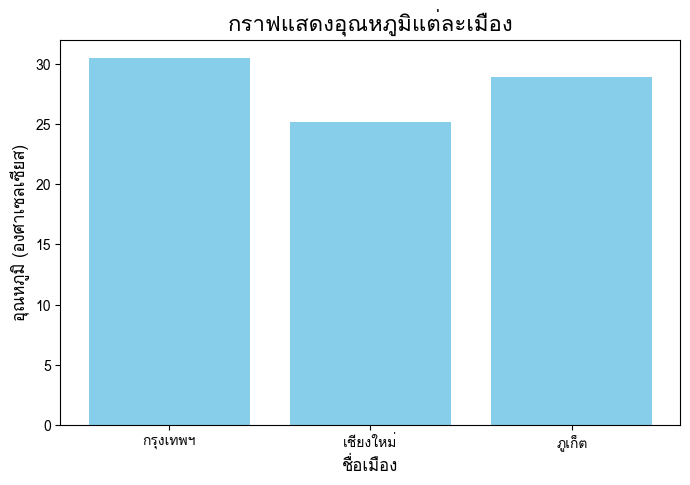

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [10]:
# คำตอบข้อ 2.1
# สร้าง Series rain_by_city: ปริมาณฝนรวมของแต่ละเมือง, index = ชื่อเมือง
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

print(rain_by_city)

city
Auckland        351.9
Bangkok         685.6
Beijing         250.1
Berlin          268.4
Buenos Aires    305.1
Cairo           123.0
Cape Town       239.3
Chiang Mai      435.6
Lagos           652.8
Lima            180.3
London          273.3
Los Angeles     169.5
Mexico City     305.9
Moscow          247.4
Mumbai          487.9
Nairobi         395.3
New York        315.2
Paris           333.4
Sao Paulo       423.2
Singapore       870.4
Sydney          331.4
Tokyo           385.1
Toronto         318.3
Name: rainfall_mm, dtype: float64


In [11]:
# 1.เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rain_cities = rain_by_city.sort_values(ascending=False).head(3)
print(top3_rain_cities)

city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64


In [12]:
# 2.สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
rain_pct_by_city = (rain_by_city / rain_by_city.sum() * 100).round(2)
print(rain_pct_by_city)

city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64


In [13]:
# 3.จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
n_above_avg = (rain_by_city > rain_by_city.mean()).sum()
print(n_above_avg)

8


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [14]:
# คำตอบข้อ 2.2
BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")

# ทำความสะอาดคอลัมน์ country ก่อน เพราะมีบางเมืองที่ตัวพิมพ์ไม่สม่ำเสมอ
# เช่น "Japan" กับ "JAPAN" ถูกนับเป็นคนละค่า ถ้าไม่ทำก่อนอาจทำให้ groupby('city')
# ได้ country ไม่ตรงกับความเป็นจริง (ขึ้นกับว่าตัวไหนมาก่อนในข้อมูล)
df["country"] = df["country"].str.title()

# สร้าง city_profile: หนึ่งแถวต่อหนึ่งเมือง
city_profile = (
    df.groupby("city")
      .agg(
          country=("country", "first"),
          region=("region", "first"),
          n_records=("record_id", "count"),
          avg_temp=("temperature_c", "mean"),
          total_rain=("rainfall_mm", "sum")
      )
      .reset_index()
)

print(city_profile)

            city       country         region  n_records   avg_temp  \
0       Auckland   New Zealand        Oceania         90  17.804444   
1        Bangkok      Thailand           Asia         91  32.453846   
2        Beijing         China           Asia         90  15.598876   
3         Berlin       Germany         Europe         90  12.383146   
4   Buenos Aires     Argentina  South America         90  19.171910   
5          Cairo         Egypt         Africa         91  26.089888   
6      Cape Town  South Africa         Africa         90  30.162921   
7     Chiang Mai      Thailand           Asia         91  29.680220   
8          Lagos       Nigeria         Africa         90  29.494253   
9           Lima          Peru  South America         90  21.490000   
10        London            Uk         Europe         90  13.490909   
11   Los Angeles           Usa  North America         90  20.657303   
12   Mexico City        Mexico  North America         90  19.187778   
13    

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [15]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [16]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [17]:
# คำตอบข้อ 3.1
BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],  # ข้อ 1
    parse_dates=["date"],                                                                # ข้อ 2
    na_values=[999, -999],                                                               # ข้อ 3
    dtype={"city": "category", "region": "category"},                                    # ข้อ 4
    index_col="city"                                                                     # ข้อ 5
)

print(df.dtypes)
print()
df.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [18]:
# คำตอบข้อ 3.2
BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

# ตารางที่นำเข้าแบบปกติ (ทุกคอลัมน์, dtype ตามที่ pandas เดาเอง)
df_normal = pd.read_csv(BASE + "world_weather_sample.csv")

# ตารางที่ปรับปรุงแล้วจากโจทย์ 3.1
df_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)

mem_normal = df_normal.memory_usage(deep=True)
mem_opt = df_opt.memory_usage(deep=True)

total_normal = mem_normal.sum()
total_opt = mem_opt.sum()
pct_reduction = (1 - total_opt / total_normal) * 100

print(mem_normal)
print(mem_opt)
print(f"หน่วยความจำเดิม: {total_normal:,} bytes")
print(f"หน่วยความจำหลังปรับ: {total_opt:,} bytes")
print(f"ลดลง: {pct_reduction:.2f}%")

Index                132
record_id          16600
date              122425
city              116920
country           114937
region            117631
temperature_c      16600
humidity_pct       16600
rainfall_mm        16600
wind_speed_kmh     16600
pressure_hpa       16600
dtype: int64
Index             3927
date             16600
region            2590
temperature_c    16600
humidity_pct     16600
rainfall_mm      16600
dtype: int64
หน่วยความจำเดิม: 571,645 bytes
หน่วยความจำหลังปรับ: 72,917 bytes
ลดลง: 87.24%


คอลัมน์ที่ช่วยลดหน่วยความจำได้มาก คือ city, country และ region เพราะข้อมูลเหล่านี้เป็นข้อความที่มีค่าซ้ำกันเยอะ เช่น มีชื่อเมืองหรือประเทศเดิมซ้ำหลายแถว จึงเปลี่ยนเป็น category เพื่อให้คอมพิวเตอร์เก็บข้อมูลซ้ำในรูปแบบรหัสแทน ทำให้ใช้พื้นที่น้อยลงมาก

นอกจากนี้ คอลัมน์ตัวเลขก็มีการเปลี่ยนเป็นชนิดข้อมูลที่ใช้พื้นที่น้อยลงด้วย จึงทำให้หน่วยความจำโดยรวม ลดจาก 571,645 bytes เหลือ 72,917 bytes หรือลดลงถึง 87.24%

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [19]:
# คำตอบข้อ 3.3
BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

overall_max = float("-inf")
overall_min = float("inf")

city_sum = {}    # สะสมผลรวมอุณหภูมิของแต่ละเมือง
city_count = {}  # สะสมจำนวนแถว (ที่ไม่ใช่ NaN) ของแต่ละเมือง

for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=300, na_values=[999, -999]):
    temp = chunk["temperature_c"]

    # ---------- ข้อ 1: max/min สะสมทีละก้อน ----------
    chunk_max, chunk_min = temp.max(), temp.min()   # .max()/.min() ข้าม NaN ให้อัตโนมัติ
    if pd.notna(chunk_max):
        overall_max = max(overall_max, chunk_max)
    if pd.notna(chunk_min):
        overall_min = min(overall_min, chunk_min)

    # ---------- ข้อ 2: สะสม sum และ count รายเมือง (ไม่สะสม mean โดยตรง) ----------
    grp = chunk.dropna(subset=["temperature_c"]).groupby("city")["temperature_c"].agg(["sum", "count"])
    for city, row in grp.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

# คำนวณค่าเฉลี่ยจริงหลังวนครบทุกก้อนแล้วเท่านั้น
city_mean = pd.Series({c: city_sum[c] / city_count[c] for c in city_sum}).sort_index()

print("อุณหภูมิสูงสุดทั้งไฟล์:", overall_max)
print("อุณหภูมิต่ำสุดทั้งไฟล์:", overall_min)
print()
print(city_mean.round(2))

อุณหภูมิสูงสุดทั้งไฟล์: 39.2
อุณหภูมิต่ำสุดทั้งไฟล์: -88.0

Auckland        17.80
Bangkok         32.45
Beijing         15.60
Berlin          12.38
Buenos Aires    19.17
Cairo           26.09
Cape Town       19.15
Chiang Mai      29.68
Lagos           29.49
Lima            21.49
London          13.49
Los Angeles     20.66
Mexico City     19.19
Moscow           7.23
Mumbai          30.87
Nairobi         21.44
New York        15.48
Paris           14.75
Sao Paulo       22.84
Singapore       29.31
Sydney          20.35
Tokyo           18.41
Toronto         11.61
dtype: float64


ถ้าเขียนแบบผิดคือ:


```
# chunk_means = []
for chunk in pd.read_csv(..., chunksize=300):
    chunk_means.append(chunk["temperature_c"].mean())
wrong_mean = sum(chunk_means) / len(chunk_means)
```



วิธีนี้ผิดเพราะเป็นการเอา "ค่าเฉลี่ยของค่าเฉลี่ย" (mean of means) ซึ่งให้น้ำหนักแต่ละก้อนเท่ากันเสมอ ทั้งที่แต่ละก้อนมีจำนวนข้อมูลไม่เท่ากัน — ตัวอย่างเช่น:

- ถ้าก้อนที่ 1 มี 300 แถว เฉลี่ย 20°C และก้อนที่ 2 มีแค่ 50 แถว (เพราะเป็นก้อนสุดท้ายที่เหลือไม่ครบ) เฉลี่ย 30°C
ค่าเฉลี่ยที่ถูกต้องของทั้งหมด (350 แถว) ต้องเป็น (300×20 + 50×30) / 350 ≈ 21.4°C
แต่ถ้าเอา (20+30)/2 = 25 จะได้ผลผิด เพราะไปให้ "น้ำหนัก" ก้อนที่มีแค่ 50 แถวเท่ากับก้อนที่มี 300 แถว ทั้งที่ควรมีอิทธิพลต่อค่าเฉลี่ยรวมน้อยกว่ามาก

ยิ่งกรณีนี้ซับซ้อนขึ้นไปอีกเมื่อต้องการค่าเฉลี่ยรายเมือง เพราะแต่ละเมืองอาจกระจายอยู่ในหลายก้อนไม่เท่ากัน บางก้อนอาจไม่มีข้อมูลเมืองนั้นเลย (count=0) ยิ่งทำให้การเฉลี่ยแบบ "เฉลี่ยของเฉลี่ย" ผิดเพี้ยนมากขึ้นตามความไม่สม่ำเสมอของการกระจายตัว

> สิ่งที่ควรสะสมแทนคือ sum และ count (ไม่ใช่ mean) แล้วค่อยหาร sum/count หลังวนครบทุกก้อนแล้วเท่านั้น

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


In [21]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

                                date  temperature_c  humidity_pct  rainfall_mm
count                           2075        2052.00       1993.00      2013.00
mean   2025-02-14 12:56:33.542168576          20.41         66.82         4.15
min              2025-01-01 00:00:00         -88.00         21.50         0.00
25%              2025-01-23 00:00:00          15.40         58.60         0.30
50%              2025-02-15 00:00:00          20.00         67.10         3.50
75%              2025-03-09 00:00:00          25.62         75.50         6.60
max              2025-03-31 00:00:00          39.20        150.00        17.60
std                              NaN           7.99         13.09         3.85
        date region  temperature_c  humidity_pct  rainfall_mm
count   2075   2075         2052.0        1993.0       2013.0
unique   NaN      6            NaN           NaN          NaN
top      NaN   Asia            NaN           NaN          NaN
freq     NaN    542            NaN       

In [22]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

date              0
region            0
temperature_c    23
humidity_pct     82
rainfall_mm      62
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 164
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [23]:
# คำตอบข้อ 4.1
n = len(df)

summary = pd.DataFrame({
    "dtype":         df.dtypes.astype(str),
    "n_missing":     df.isna().sum(),
    "pct_missing":   (df.isna().mean() * 100).round(2),
    "n_unique":      df.nunique(dropna=True),
    "example_value": df.bfill().iloc[0]   # ค่าแรกที่ไม่ใช่ NaN ของแต่ละคอลัมน์
}).sort_values("n_missing", ascending=False)

print(summary)

                        dtype  n_missing  pct_missing  n_unique  \
humidity_pct          float64         82         3.95       544   
rainfall_mm           float64         62         2.99       164   
temperature_c         float64         23         1.11       330   
date           datetime64[ns]          0         0.00        90   
region               category          0         0.00         6   

                     example_value  
humidity_pct                  72.6  
rainfall_mm                    6.3  
temperature_c                 15.7  
date           2025-03-24 00:00:00  
region               North America  


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [24]:
# คำตอบข้อ 4.2
# ใช้ .notna() ควบคู่กับ .between() เสมอ เพราะ NaN.between(...)
# จะประเมินเป็น False → พอ negate (~) ด้วย NOT จะกลายเป็น True
# ทำให้แถวที่เป็นค่าว่างถูกนับเป็น "ผิดปกติ" ไปด้วยโดยไม่ตั้งใจ

# 1) temperature_c นอกช่วง -60 ถึง 60
temp_out = df['temperature_c'].notna() & ~df['temperature_c'].between(-60, 60)
n_temp_out = temp_out.sum()
print("1) temperature_c out of range:", n_temp_out)

1) temperature_c out of range: 2


In [25]:
# 2) humidity_pct นอกช่วง 0 ถึง 100
hum_out = df['humidity_pct'].notna() & ~df['humidity_pct'].between(0, 100)
n_hum_out = hum_out.sum()
print("2) humidity_pct out of range:", n_hum_out)

2) humidity_pct out of range: 3


In [26]:
# 3) แถวที่ผิดปกติอย่างน้อยหนึ่งคอลัมน์ — ใช้ OR (|) รวม mask แล้ว sum ครั้งเดียว
# เพื่อไม่ให้แถวที่ผิดปกติทั้งสองคอลัมน์ถูกนับซ้ำ (ต่างจากการเอา n_temp_out + n_hum_out มาบวกกันตรงๆ)
any_out = temp_out | hum_out
n_any_out = any_out.sum()
print("3) any anomaly (no double count):", n_any_out)

3) any anomaly (no double count): 5


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [27]:
# คำตอบข้อ 4.3
# อ่านข้อมูลใหม่แบบเต็ม เพื่อให้มีคอลัมน์ country
df_raw = pd.read_csv(BASE + "world_weather_sample.csv")

# ---------- ข้อ 1 ----------
dup_groups = (
    df_raw["country"].drop_duplicates()
    .groupby(df_raw["country"].drop_duplicates().str.upper())
    .apply(list)
)
dup_groups = dup_groups[dup_groups.apply(len) > 1]
print(dup_groups)

country
ARGENTINA          [Argentina, ARGENTINA]
CANADA                   [Canada, CANADA]
GERMANY                [Germany, GERMANY]
JAPAN                      [Japan, JAPAN]
KENYA                      [Kenya, KENYA]
NEW ZEALAND    [New Zealand, NEW ZEALAND]
SINGAPORE          [Singapore, SINGAPORE]
Name: country, dtype: object


In [28]:
# ---------- ข้อ 2 ----------
titled = df_raw["country"].str.title()
print(sorted(titled.unique()))
print(titled.nunique())

['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'Uk', 'Usa']
21


.str.title() ทำงานด้วยกฎเดียวคือทำตัวอักษรแรกของทุกคำเป็นตัวพิมพ์ใหญ่ ส่วนตัวอักษรที่เหลือในคำนั้นบังคับให้เป็นตัวพิมพ์เล็กเสมอ โดยไม่แยกแยะว่าคำนั้นเป็นชื่อเต็มหรือตัวย่อ (acronym)

ชื่อเต็มของประเทศ เช่น "NEW ZEALAND" → กลายเป็น "New Zealand" ซึ่งถูกต้อง เพราะรูปแบบที่ถูกของชื่อเต็มคือ title case อยู่แล้ว
แต่ "UK" และ "USA" เป็นตัวย่อ ซึ่งตามหลักการเขียนภาษาอังกฤษต้องเป็นตัวพิมพ์ใหญ่ทั้งหมดเสมอ เมื่อผ่าน .title() จะถูกแปลงเป็น "Uk" และ "Usa" ซึ่งเป็นรูปแบบที่ไม่ถูกต้องของตัวย่อเหล่านี้

พูดง่ายๆ คือ .str.title() ไม่รู้จักแนวคิดเรื่อง "ตัวย่อ" มันจึงไป "แก้" ข้อมูลของ UK/USA ที่ถูกต้องอยู่แล้วให้กลายเป็นผิด ทั้งที่สองประเทศนี้ไม่ได้มีปัญหาตัวพิมพ์ไม่สม่ำเสมอตั้งแต่แรก (ในข้อมูลดิบมีแค่ "UK" และ "USA" รูปแบบเดียว ไม่มี "uk" หรือ "Usa" ปนมา) — ความเสียหายนี้จึงเกิดขึ้นแม้กับข้อมูลที่สะอาดอยู่แล้วก็ตาม

In [29]:
# ---------- ข้อ 3 ----------
key = df_raw["country"].str.strip().str.upper()
ACRONYMS = {"UK", "USA"}

df_raw["country_clean"] = np.where(
    key.isin(ACRONYMS),
    key,
    df_raw["country"].str.strip().str.title()
)

print(df_raw["country_clean"].nunique())
print(sorted(df_raw["country_clean"].unique()))

21
['Argentina', 'Australia', 'Brazil', 'Canada', 'China', 'Egypt', 'France', 'Germany', 'India', 'Japan', 'Kenya', 'Mexico', 'New Zealand', 'Nigeria', 'Peru', 'Russia', 'Singapore', 'South Africa', 'Thailand', 'UK', 'USA']


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [30]:
# มีการแก้ไขโค้ดอาจารย์
# city ถูกตั้งเป็น index ไปแล้วตั้งแต่ข้อ 3.1 (index_col="city")
# ดังนั้นตอนนี้ df.columns มีแค่: date, region, temperature_c, humidity_pct, rainfall_mm
# "city" ไม่ใช่คอลัมน์อีกต่อไป จึงเอาไปใส่ใน .loc[..., ["city", ...]] ไม่ได้

# วิธีแก้: ใช้ .reset_index() เพื่อดึง city กลับมาเป็นคอลัมน์ปกติชั่วคราว
df_reset = df.reset_index()
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df_reset.iloc[0:3, 0:3].shape, df_reset.loc[0:3, ["city", "region"]].shape)
# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df_reset.loc[df_reset["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
        city       date  temperature_c
161  Bangkok 2025-02-14           38.6
325   Mumbai 2025-03-31           35.6
343  Bangkok 2025-01-26           37.2


In [31]:
# มีการแก้ไขโค้ดอาจารย์
# ต้อง reset_index() ก่อนเสมอ เพราะ city เป็น index อยู่แล้ว ไม่ใช่คอลัมน์
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.reset_index().set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 4)
                   date  temperature_c
region city                           
Asia   Tokyo 2025-02-09           18.3
       Tokyo 2025-03-21           19.7
       Tokyo 2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [32]:
# คำตอบข้อ 5.1
# 1) แถวที่ตำแหน่งเลขคู่ (0, 2, 4, ...) 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย
part1 = df.iloc[0:20:2, -3:]
print(part1)

# 2) ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน
part2 = df.iloc[-1:-6:-1, :]
print(part2)

# 3) ค่าเดี่ยวที่แถวกึ่งกลางตาราง คอลัมน์สุดท้าย
n = df.shape[0]          # จำนวนแถวทั้งหมด (คำนวณจาก df โดยตรง ไม่ hardcode)
mid = n // 2              # ตำแหน่งกึ่งกลาง
part3 = df.iloc[mid, -1]
print(part3)

              temperature_c  humidity_pct  rainfall_mm
city                                                  
New York               15.7          72.6          6.3
Los Angeles            20.6          46.8          1.2
Cape Town              19.1          55.0          0.0
Buenos Aires           22.1          63.4          2.7
Buenos Aires           20.8          58.7          1.6
Moscow                  6.0          70.8          0.0
Beijing                14.3          38.5          0.0
Buenos Aires           19.2          64.9          2.2
Buenos Aires           19.4          69.3          8.3
Lagos                  28.8          70.5          8.9
                  date         region  temperature_c  humidity_pct  \
city                                                                 
Paris       2025-01-12         Europe           11.1          65.8   
Toronto     2025-02-09  North America            NaN          65.0   
Nairobi     2025-01-28         Africa           21.7        

df.iloc[0:20:2, -3:] — slice แถว 0:20:2 หมายถึง เริ่มตำแหน่ง 0 ถึงก่อน 20 ก้าวทีละ 2 (จึงได้ตำแหน่ง 0,2,4,...,18 รวม 10 แถวพอดี) ส่วนคอลัมน์ -3: คือ "3 คอลัมน์สุดท้ายเป็นต้นไป" โดยไม่ต้องรู้ชื่อหรือจำนวนคอลัมน์ทั้งหมดเลย

df.iloc[-1:-6:-1, :] — เริ่มจากตำแหน่ง -1 (แถวสุดท้าย) ไปจนถึงก่อนตำแหน่ง -6 โดยก้าวทีละ -1 (ถอยหลัง) จึงได้ตำแหน่ง -1,-2,-3,-4,-5 ซึ่งตรงกับ "5 แถวสุดท้าย เรียงจากล่างขึ้นบน" อยู่แล้วในตัว ไม่ต้องกลับลำดับเพิ่ม

n = df.shape[0] แล้วคำนวณ mid = n // 2 เพื่อหาตำแหน่งกึ่งกลางแบบไดนามิกจากจำนวนแถวจริง (ไม่ hardcode เลข 2075) จากนั้น .iloc[mid, -1] ระบุทั้งตำแหน่งแถว (integer เดี่ยว) และตำแหน่งคอลัมน์สุดท้าย (-1) พร้อมกัน ผลลัพธ์จึงเป็นค่าสเกลาร์ (scalar) ตัวเดียว ไม่ใช่ Series หรือ DataFrame

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [33]:
# คำตอบข้อ 5.2
# ตั้ง MultiIndex (region, city) และ sort_index() ก่อนใช้งาน
multi = df.reset_index().set_index(["region", "city"]).sort_index()

# ---------- ข้อ 1: ข้อมูล Asia ทั้งหมด เฉพาะคอลัมน์ date, temperature_c ----------
part1 = multi.loc["Asia", ["date", "temperature_c"]]
print(part1)
# ---------- ข้อ 2: Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว ----------
# ใช้ pd.IndexSlice เพื่อเลือกทุก region (:) แต่กรอง city ด้วยลิสต์
idx = pd.IndexSlice
part2 = multi.loc[idx[:, ["Tokyo", "Bangkok"]], :]
print(part2)
# ---------- ข้อ 3: ทุกภูมิภาค เฉพาะเมืองที่ขึ้นต้นด้วย B ----------
mask = multi.index.get_level_values("city").str.startswith("B")
part3 = multi.loc[mask]
print(part3)

              date  temperature_c
city                             
Bangkok 2025-02-22           30.8
Bangkok 2025-01-10           28.9
Bangkok 2025-01-27           27.9
Bangkok 2025-01-03           29.0
Bangkok 2025-03-28           31.0
...            ...            ...
Tokyo   2025-01-08           15.3
Tokyo   2025-02-19           19.1
Tokyo   2025-01-02           16.3
Tokyo   2025-03-30           20.4
Tokyo   2025-03-06           16.6

[542 rows x 2 columns]
                     date  temperature_c  humidity_pct  rainfall_mm
region city                                                        
Asia   Tokyo   2025-02-09           18.3          60.6          0.0
       Tokyo   2025-03-21           19.7          67.4          2.8
       Tokyo   2025-03-23           17.7          60.2          4.0
       Tokyo   2025-01-23           20.8          61.6         12.3
       Tokyo   2025-02-07           19.5          68.2          5.0
...                   ...            ...           ...    

ข้อ 1 — part1 ได้ 542 แถว, 2 คอลัมน์ (date, temperature_c) เป็นข้อมูลทุกเมืองในภูมิภาค Asia

ข้อ 2 — part2 ได้ 181 แถว, 4 คอลัมน์ สังเกตว่า region ที่ปรากฏในผลลัพธ์มีแต่ Asia เพียงค่าเดียว (ไม่มี region อื่นเลย) เพราะทั้ง Tokyo และ Bangkok บังเอิญอยู่ในภูมิภาค Asia ทั้งคู่ — นี่คือพฤติกรรมที่ถูกต้องของ pd.IndexSlice[:, ["Tokyo","Bangkok"]] คือ "เลือกทุก region (:) แต่กรองเฉพาะ city ที่อยู่ในลิสต์" ถ้าบังเอิญเมืองที่เลือกมาอยู่ region เดียวกันหมด ผลลัพธ์ก็จะมี region เดียวเป็นเรื่องปกติ ไม่ใช่ bug

ข้อ 3 — part3 ได้ 361 แถว ครอบคลุม 4 เมือง (Bangkok, Beijing, Berlin, Buenos Aires) กระจายอยู่คนละภูมิภาคกัน — สังเกตว่า Bangkok อยู่ Asia แต่ Buenos Aires อยู่ South America ซึ่งแสดงให้เห็นว่า mask ที่กรองด้วย get_level_values("city").str.startswith("B") ทำงานข้าม region ได้ถูกต้องตามที่โจทย์ต้องการ (เลือกทุกภูมิภาค เฉพาะเมืองขึ้นต้นด้วย B)

จุดที่น่าสังเกตเพิ่มเติม: ในข้อ 3 มีค่า humidity_pct = 150.0 ที่แถว Bangkok วันที่ 2025-02-25 โผล่มาด้วย — นี่คือหนึ่งในค่าผิดปกติทางกายภาพที่เจอไปแล้วในโจทย์ 4.2 (ความชื้นเกิน 100%) ยืนยันว่าข้อมูลผิดปกตินั้นยังคงอยู่ใน multi เพราะเรายังไม่ได้ทำความสะอาดขั้นตอนนั้นจริงกับ DataFrame หลัก มีแค่สร้าง mask ไปนับจำนวนเฉยๆ ก่อนหน้านี้

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [34]:
# คำตอบข้อ 5.3
subset = df[df.index == "Bangkok"].copy()
subset["temperature_c"] = 0   # แก้ subset ได้อย่างปลอดภัย ไม่กระทบ df ต้นฉบับแน่นอน

ต้องการแก้ต้นฉบับ ใช้ .loc[เงื่อนไข, คอลัมน์] = ค่า ในคำสั่งเดียว ต้องการสำเนาแยก ใส่ .copy() ทันทีหลัง filter เสมอ ไม่ปล่อยให้ pandas เดาเจตนาแทนเรา

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [35]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df.index.isin(["Bangkok", "Tokyo"])])) # ใช้ df.index.isin(...) แทน df["city"].isin(...)
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

235
1894
757
295


In [36]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 23
15.0 17.6


In [37]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .reset_index()                                  # ดึง city กลับมาเป็นคอลัมน์
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

      city  temperature_c  is_hot
0    Tokyo           18.3   False
1   Mumbai           31.0    True
2  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [38]:
# คำตอบข้อ 6.1
BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

# ใช้ dataset เต็มอีกครั้ง เพราะ df จากข้อ 3.1 ไม่มีคอลัมน์ wind_speed_kmh (ถูกตัดออกด้วย usecols)
df_full = pd.read_csv(BASE + "world_weather_sample.csv", na_values=[999, -999])

# ---------- ข้อ 1: Asia, ฝน > 5mm, ลม > 20 km/h ----------
cond1 = (df_full["region"] == "Asia") & (df_full["rainfall_mm"] > 5) & (df_full["wind_speed_kmh"] > 20)
r1 = df_full[cond1]

# ---------- ข้อ 2: ไม่ใช่ Bangkok/Tokyo/London และความชื้น 40-60 ----------
cond2 = (~df_full["city"].isin(["Bangkok", "Tokyo", "London"])) & (df_full["humidity_pct"].between(40, 60))
r2 = df_full[cond2]

# ---------- ข้อ 3: แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป ----------
n_missing_per_row = df_full.isna().sum(axis=1)   # นับค่าว่างรายแถว (axis=1 = นับข้ามคอลัมน์)
cond3 = n_missing_per_row >= 2
r3 = df_full[cond3]

# ---------- ข้อ 4: ชื่อเมืองมีคำว่า New หรือ San (regex) ----------
cond4 = df_full["city"].str.contains(r"New|San", regex=True)
r4 = df_full[cond4]

print("1)", len(r1))
print("2)", len(r2))
print("3)", len(r3))
print("4)", len(r4), r4["city"].unique())

1) 54
2) 470
3) 8
4) 90 ['New York']


1. 54 แถว — ใช้ & เชื่อมสามเงื่อนไข ต้องครอบวงเล็บทุกเงื่อนไขตามกฎที่เคยพบในโจทย์ก่อนหน้า

2. 470 แถว — ~df["city"].isin([...]) คือ "ไม่ใช่หนึ่งในลิสต์" ส่วน .between(40, 60) รวมปลายช่วงทั้งสองด้าน (40 และ 60 ถูกนับด้วย)

3. 8 แถว — df.isna().sum(axis=1) นับจำนวนค่าว่างรายแถว (ต่างจาก axis=0/ค่า default ที่นับรายคอลัมน์) แล้วกรองแถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป

4. 90 แถว แต่มีแค่เมือง New York เท่านั้นที่ match — เพราะในข้อมูลนี้ไม่มีเมืองไหนที่ชื่อมีคำว่า "San" ประกอบอยู่จริงๆ (มี "Sao Paulo" แต่สะกดเป็น "Sao" ไม่ใช่ "San" จึงไม่ match) รูปแบบ regex "New|San" ใช้ | หมายถึง "หรือ" แบบเดียวกับใน regular expression ทั่วไป และค่า default ของ .str.contains() คือค้นหาแบบ case-sensitive และไม่ต้อง match ทั้งคำ (substring ก็พอ)

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [39]:
# คำตอบข้อ 6.2
df["temperature_c_clean"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
p99 = df["rainfall_mm"].quantile(0.99)
df["rainfall_mm_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > p99, p99)
# ---------- คอลัมน์ 1: temperature_c ที่แทนค่าผิดปกติด้วยค่าว่าง (.where) ----------
# .where(cond) เก็บค่าเดิมไว้เมื่อ cond เป็น True เท่านั้น ส่วนที่ cond เป็น False จะถูกแทนด้วย NaN (ค่า default)
df["temperature_c_clean"] = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

# ---------- คอลัมน์ 2: rainfall_mm ที่จำกัดค่าสูงสุดไว้ที่ percentile 99 (.mask) ----------
# .mask(cond, other) ทำตรงข้ามกับ .where(): แทนที่ค่าด้วย other เมื่อ cond เป็น True เท่านั้น
p99 = df["rainfall_mm"].quantile(0.99)
df["rainfall_mm_capped"] = df["rainfall_mm"].mask(df["rainfall_mm"] > p99, p99)

print(df[["temperature_c", "temperature_c_clean", "rainfall_mm", "rainfall_mm_capped"]].head())

             temperature_c  temperature_c_clean  rainfall_mm  \
city                                                           
New York              15.7                 15.7          6.3   
Tokyo                 18.3                 18.3          0.0   
Los Angeles           20.6                 20.6          1.2   
Mumbai                31.0                 31.0          8.0   
Cape Town             19.1                 19.1          0.0   

             rainfall_mm_capped  
city                             
New York                    6.3  
Tokyo                       0.0  
Los Angeles                 1.2  
Mumbai                      8.0  
Cape Town                   0.0  


- ค่า percentile ที่ 99 ของ rainfall_mm คือ 14.688 มม. — ค่าที่เกินนี้ (มี 21 แถว) จะถูกดึงลงมาเท่ากับ 14.688 พอดี (max หลัง cap = 14.688 จาก max เดิม 17.6)

- temperature_c_clean มีค่าว่างเพิ่มจากเดิม 23 เป็น 25 ค่า (23 ค่าว่างเดิม + 2 ค่าที่ผิดปกติทางกายภาพ -88.0 ที่พบตั้งแต่ 4.2 ถูกแปลงเป็น NaN เพิ่ม)

- จำนวนแถวของ df ไม่เปลี่ยนเลย (ยังเป็น 2,075 แถวเท่าเดิม) เพราะทั้ง .where() และ .mask() ไม่ได้ลบแถวใดๆ ออก เพียงแค่แทนที่ค่าในเซลล์เท่านั้น

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [40]:
# คำตอบข้อ 6.3
work = (df.reset_index()[["city", "date", "temperature_c_clean"]]
          .rename(columns={"temperature_c_clean": "temperature_c"})
          .dropna(subset=["temperature_c"])
          .reset_index(drop=True))
# ค่าเฉลี่ยของแต่ละเมือง (broadcast กลับมาทุกแถวด้วย transform)
work["city_mean"] = work.groupby("city", observed=True)["temperature_c"].transform("mean")
# deviation = ค่าจริง - ค่าเฉลี่ยของเมืองตัวเอง (มีเครื่องหมาย +/- บอกทิศทางด้วย)
work["deviation"] = work["temperature_c"] - work["city_mean"]
work["abs_deviation"] = work["deviation"].abs()
# หาตำแหน่งแถวที่ abs_deviation มากที่สุดของแต่ละเมือง
idx = work.groupby("city", observed=True)["abs_deviation"].idxmax()

result_63 = (work.loc[idx, ["city", "date", "temperature_c", "deviation"]]
                  .sort_values("city").reset_index(drop=True))

print(result_63)

            city       date  temperature_c  deviation
0       Auckland 2025-02-27           25.6   7.795556
1        Bangkok 2025-03-26           39.1   6.646154
2        Beijing 2025-03-06           22.6   7.001124
3         Berlin 2025-03-26           19.4   7.016854
4   Buenos Aires 2025-01-02           12.2  -8.189773
5          Cairo 2025-03-31           33.6   7.510112
6      Cape Town 2025-03-23           25.5   6.346591
7     Chiang Mai 2025-03-28           37.3   7.619780
8          Lagos 2025-01-01           21.1  -8.394253
9           Lima 2025-01-22           12.9  -8.590000
10        London 2025-02-09           23.4   9.909091
11   Los Angeles 2025-01-09           13.4  -7.257303
12   Mexico City 2025-02-24           26.5   7.312222
13        Moscow 2025-01-20           -0.2  -7.433333
14        Mumbai 2025-01-07           24.2  -6.672222
15       Nairobi 2025-03-11           27.8   6.360000
16      New York 2025-03-16           24.5   9.023333
17         Paris 2025-01-04 

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [41]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
                  date year_month  is_weekend
city                                         
New York    2025-03-24    2025-03       False
Tokyo       2025-02-09    2025-02        True
Los Angeles 2025-02-01    2025-02        True


In [42]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
# city เป็น index อยู่แล้ว ใช้ .loc["Bangkok"] แทน df["city"]=="Bangkok"
bkk = df.loc["Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [43]:
# คำตอบข้อ 7.1
df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),   # เช่น "2025-03"
    week_of_year=df["date"].dt.isocalendar().week,         # สัปดาห์ที่เท่าไรของปี (ISO week)
    day_name=df["date"].dt.day_name(),                     # ชื่อวันในสัปดาห์ เช่น "Monday"
    is_weekend=df["date"].dt.dayofweek >= 5                # True ถ้าเป็นเสาร์(5)/อาทิตย์(6)
)

print(df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head(8))

                   date year_month  week_of_year  day_name  is_weekend
city                                                                  
New York     2025-03-24    2025-03            13    Monday       False
Tokyo        2025-02-09    2025-02             6    Sunday        True
Los Angeles  2025-02-01    2025-02             5  Saturday        True
Mumbai       2025-01-19    2025-01             3    Sunday        True
Cape Town    2025-02-03    2025-02             6    Monday       False
Auckland     2025-03-18    2025-03            12   Tuesday       False
Buenos Aires 2025-02-13    2025-02             7  Thursday       False
Mexico City  2025-02-15    2025-02             7  Saturday        True


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [44]:
# คำตอบข้อ 7.2
# ---------- ข้อ 1: ช่วงวันที่ครอบคลุม + วันที่ขาดหาย ----------
min_date, max_date = df["date"].min(), df["date"].max()
n_days_covered = (max_date - min_date).days + 1        # +1 เพราะนับรวมทั้งวันแรกและวันสุดท้าย

full_range = pd.date_range(min_date, max_date, freq="D")   # วันครบทุกวันในช่วง (ไม่มีวันขาด)
dates_present = pd.Index(df["date"].unique())               # วันที่ที่มีข้อมูลจริง
missing_dates = full_range.difference(dates_present)        # วันที่อยู่ใน full_range แต่ไม่มีใน dates_present

print("ช่วงข้อมูล:", min_date.date(), "ถึง", max_date.date())
print("จำนวนวันทั้งหมดในช่วง:", n_days_covered)
print("จำนวนวันที่ไม่มีข้อมูลเลย:", len(missing_dates))

ช่วงข้อมูล: 2025-01-01 ถึง 2025-03-31
จำนวนวันทั้งหมดในช่วง: 90
จำนวนวันที่ไม่มีข้อมูลเลย: 0


In [45]:
# ---------- ข้อ 2: temp เฉลี่ย weekend vs weekday จำแนกตาม region ----------
part2 = (df.groupby(["region", "is_weekend"], observed=True)["temperature_c_clean"]
            .mean().round(2).unstack())
part2.columns = ["weekday_avg", "weekend_avg"]
part2["diff"] = (part2["weekend_avg"] - part2["weekday_avg"]).round(2)
print(part2)

               weekday_avg  weekend_avg  diff
region                                       
Africa               24.08        23.88 -0.20
Asia                 26.25        26.53  0.28
Europe               11.93        11.95  0.02
North America        16.72        16.84  0.12
Oceania              18.94        19.40  0.46
South America        21.70        21.26 -0.44


In [46]:
# ---------- ข้อ 3: เดือนที่ฝนรวมสูงสุดของแต่ละเมือง ----------
monthly_rain = (df.reset_index()
                   .groupby(["city", "year_month"], observed=True)["rainfall_mm"]
                   .sum())
idx3 = monthly_rain.groupby("city", observed=True).idxmax()
part3 = (monthly_rain.loc[idx3]
                      .reset_index(name="total_rainfall")
                      .sort_values("city")
                      .reset_index(drop=True))
print(part3)

            city year_month  total_rainfall
0       Auckland    2025-03           150.0
1        Bangkok    2025-02           243.9
2        Beijing    2025-02            87.4
3         Berlin    2025-03           100.1
4   Buenos Aires    2025-02           121.2
5          Cairo    2025-02            48.0
6      Cape Town    2025-01            98.3
7     Chiang Mai    2025-03           188.0
8          Lagos    2025-03           233.0
9           Lima    2025-01            88.0
10        London    2025-01           117.2
11   Los Angeles    2025-01            78.6
12   Mexico City    2025-01           124.2
13        Moscow    2025-02            93.6
14        Mumbai    2025-02           171.9
15       Nairobi    2025-01           178.2
16      New York    2025-01           113.6
17         Paris    2025-03           122.5
18     Sao Paulo    2025-03           155.2
19     Singapore    2025-01           321.4
20        Sydney    2025-01           134.2
21         Tokyo    2025-01     

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [47]:
# คำตอบข้อ 7.3
bkk = df.loc["Bangkok"].set_index("date").sort_index()

summary = bkk.resample("7D").agg(
    avg_temperature=("temperature_c", "mean"),
    total_rainfall=("rainfall_mm", "sum")
).round(2)

print(summary)

            avg_temperature  total_rainfall
date                                       
2025-01-01            30.36            65.7
2025-01-08            31.09            47.6
2025-01-15            30.39            58.7
2025-01-22            32.29            50.0
2025-01-29            31.76            55.4
2025-02-05            33.03            65.1
2025-02-12            34.21            60.2
2025-02-19            32.30            42.5
2025-02-26            32.34            61.7
2025-03-05            32.99            49.1
2025-03-12            33.04            56.4
2025-03-19            33.16            41.9
2025-03-26            35.40            31.3


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [48]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

23 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


/tmp/ipykernel_2770/1444335474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("city")["temperature_c"].transform("mean")
/tmp/ipykernel_2770/1444335474.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ffilled = sorted_df.groupby("city")["temperature_c"].ffill()


In [49]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
df_reset = df.reset_index()

print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df_reset.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df_reset.drop_duplicates(subset=["city", "date"]).shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [50]:
# คำตอบข้อ 8.1
# 1) คอลัมน์ที่มีค่าว่างมากที่สุด
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct.round(2))

humidity_pct           3.95
rainfall_mm            2.99
rainfall_mm_capped     2.99
temperature_c_clean    1.20
temperature_c          1.11
region                 0.00
date                   0.00
year_month             0.00
week_of_year           0.00
day_name               0.00
is_weekend             0.00
dtype: float64


In [51]:
# 2) สัดส่วนค่าว่าง temperature_c จำแนกตามเมือง
by_city = (df.groupby(df.index, observed=True)["temperature_c"]
             .apply(lambda s: s.isna().mean() * 100).round(2)
             .sort_values(ascending=False))
print(by_city)

city
Lagos           3.33
London          2.22
Cape Town       2.22
Paris           2.22
Toronto         2.22
Tokyo           2.22
Cairo           2.20
Beijing         1.11
Sao Paulo       1.11
Berlin          1.11
Buenos Aires    1.11
Los Angeles     1.11
Singapore       1.11
Moscow          1.10
Nairobi         1.10
Auckland        0.00
Bangkok         0.00
Chiang Mai      0.00
Lima            0.00
Mumbai          0.00
Mexico City     0.00
New York        0.00
Sydney          0.00
Name: temperature_c, dtype: float64


In [52]:
# 3) เหลือข้อมูลกี่ % หลัง dropna() และเมืองไหนสูญเสียมากที่สุด
n_before, n_after = len(df), len(df.dropna())
print(f"เหลือ {n_after/n_before*100:.2f}%")

count_before = df.groupby(df.index, observed=True).size()
count_after = df.dropna().groupby(df.dropna().index, observed=True).size()
loss = (count_before - count_after).sort_values(ascending=False)
print(loss.head())

เหลือ 92.00%
city
Auckland       12
Lagos          10
Cape Town       9
Nairobi         9
Los Angeles     9
dtype: int64


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [53]:
# คำตอบข้อ 8.2
work = df.reset_index()[["city", "date", "temperature_c"]].copy()

# วิธี 1: ค่าเฉลี่ยรวมทั้งตาราง
overall_mean = work["temperature_c"].mean()
work["fill_overall_mean"] = work["temperature_c"].fillna(overall_mean)

# วิธี 2: ค่าเฉลี่ยของเมืองตนเอง
work["city_mean"] = work.groupby("city", observed=True)["temperature_c"].transform("mean")
work["fill_city_mean"] = work["temperature_c"].fillna(work["city_mean"])

# วิธี 3: ค่าของวันก่อนหน้าภายในเมืองเดียวกัน
work_sorted = work.sort_values(["city", "date"]).copy()
work_sorted["fill_ffill"] = work_sorted.groupby("city", observed=True)["temperature_c"].ffill()
work = work.merge(work_sorted[["city", "date", "fill_ffill"]], on=["city", "date"], how="left")

summary = pd.DataFrame({
    "original_mean": work.groupby("city", observed=True)["temperature_c"].mean(),
    "original_std":  work.groupby("city", observed=True)["temperature_c"].std(),
    "overall_mean_fill_std":  work.groupby("city", observed=True)["fill_overall_mean"].std(),
    "city_mean_fill_std":     work.groupby("city", observed=True)["fill_city_mean"].std(),
    "ffill_std":              work.groupby("city", observed=True)["fill_ffill"].std(),
}).round(2)
print(summary)

              original_mean  original_std  overall_mean_fill_std  \
city                                                               
Auckland              17.80          2.80                   2.80   
Bangkok               32.48          2.46                   2.46   
Beijing               15.60          2.87                   2.90   
Berlin                12.38          2.60                   2.72   
Buenos Aires          19.17         11.82                  11.75   
Cairo                 26.13          2.71                   2.81   
Cape Town             19.15          2.74                   2.72   
Chiang Mai            29.74          2.85                   2.85   
Lagos                 29.49          2.84                   3.24   
Lima                  21.49          3.11                   3.11   
London                13.49          3.02                   3.16   
Los Angeles           20.66          3.02                   3.00   
Mexico City           19.19          2.74       

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [54]:
# คำตอบข้อ 8.3

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

# โหลดข้อมูลดิบใหม่ทั้งหมด
df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)
df_r = df.reset_index()

# ---------- ข้อ 1: จำนวนคู่ (city, date) ที่ซ้ำ ----------
n_dup_pairs = df_r.duplicated(subset=["city", "date"]).sum()
print("จำนวนคู่ (city, date) ที่ซ้ำ:", n_dup_pairs)


จำนวนคู่ (city, date) ที่ซ้ำ: 5


In [55]:

# ---------- ข้อ 2: ซ้ำทุกคอลัมน์ หรือซ้ำแค่คีย์ ----------
full_dup = df_r.duplicated().sum()
key_dup = df_r.duplicated(subset=["city", "date"]).sum()
print(f"ซ้ำทุกคอลัมน์: {full_dup} | ซ้ำตามคีย์: {key_dup}  (เท่ากัน → ซ้ำทุกคอลัมน์จริง)")

evidence = df_r[df_r.duplicated(subset=["city", "date"], keep=False)].sort_values(["city", "date"])
print(evidence)

ซ้ำทุกคอลัมน์: 5 | ซ้ำตามคีย์: 5  (เท่ากัน → ซ้ำทุกคอลัมน์จริง)
            city       date  region  temperature_c  humidity_pct  rainfall_mm
507      Bangkok 2025-03-03    Asia           33.8          85.2          5.6
1304     Bangkok 2025-03-03    Asia           33.8          85.2          5.6
1392       Cairo 2025-02-25  Africa           27.8          37.8          0.6
1517       Cairo 2025-02-25  Africa           27.8          37.8          0.6
569   Chiang Mai 2025-03-06    Asia           32.4          60.5          7.5
1777  Chiang Mai 2025-03-06    Asia           32.4          60.5          7.5
566       Moscow 2025-03-13  Europe           10.9          67.1          0.5
1077      Moscow 2025-03-13  Europe           10.9          67.1          0.5
1948     Nairobi 2025-02-23  Africa           22.4          57.9          4.3
2010     Nairobi 2025-02-23  Africa           22.4          57.9          4.3


In [56]:
# ---------- ข้อ 3: ขจัดข้อมูลซ้ำ + ตรวจสอบ ----------
# นโยบาย: keep="first" — เพราะพิสูจน์แล้วว่าทุกคู่ที่ซ้ำมีค่าตรงกันทุกคอลัมน์ (full duplicate)
# จึงไม่มีความขัดแย้งของข้อมูล เก็บแถวไหนก่อนก็ให้ผลเหมือนกัน
df_dedup = df_r.drop_duplicates(subset=["city", "date"], keep="first")

n_final = len(df_dedup)
n_check = df_dedup["city"].nunique() * df_dedup["date"].nunique()
print(f"หลัง dedup เหลือ {n_final} แถว = {df_dedup['city'].nunique()} เมือง × {df_dedup['date'].nunique()} วัน = {n_check}")
print("ตรงกันหรือไม่:", n_final == n_check)

หลัง dedup เหลือ 2070 แถว = 23 เมือง × 90 วัน = 2070
ตรงกันหรือไม่: True


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [57]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 6)


### ตัวอย่าง

In [58]:
# โหลด wind_speed_kmh พร้อม city, date เพื่อใช้เป็นคีย์ตอน merge (ไม่ใช้ .values ตรงๆ)
wind = pd.read_csv(BASE + "world_weather_sample.csv",
                    usecols=["city", "date", "wind_speed_kmh"],
                    parse_dates=["date"], na_values=[999, -999])
wind = wind.drop_duplicates(subset=["city", "date"])   # dedup wind ด้วยนโยบายเดียวกันกับ df

# merge บนคีย์ (city, date) — ปลอดภัยไม่ว่า df จะมีกี่แถวก็ตาม
df = df.reset_index().merge(wind, on=["city", "date"], how="left").set_index("city")

print(len(df))   # 2070 — ตรงกับ df เดิม

2070


In [59]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city", observed=True).agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city", observed=True).agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [60]:
# คำตอบข้อ 9.1
summary = df.groupby("city", observed=True).agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),
).round(2)

print(summary)

              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland         17.80        17.55      2.80       351.9                6   
Bangkok          32.44        32.50      2.49       680.0               23   
Beijing          15.60        15.50      2.87       250.1                2   
Berlin           12.38        12.30      2.60       268.4                6   
Buenos Aires     19.17        20.70     11.82       305.1                9   
Cairo            26.07        25.80      2.74       122.4                1   
Cape Town        19.15        18.85      2.74       239.3                0   
Chiang Mai       29.65        29.50      2.86       428.1                9   
Lagos            29.49        29.80      2.84       652.8               22   
Lima             21.49        21.30      3.11       180.3                1   
London           13.49        13.50      3.02       273.3       

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [61]:
# คำตอบข้อ 9.2
df["month"] = df["date"].dt.month

# สร้างตารางสรุป จำแนกตาม region และ month พร้อมกัน
summary = (df.groupby(["region", "month"], observed=True)["temperature_c"]
              .mean()
              .reset_index(name="avg_temp")   # จัดกลับเป็นตารางปกติ (ไม่ใช่ MultiIndex Series)
              .round({"avg_temp": 2}))

print(summary)

# หาคู่ (region, month) ที่มีอุณหภูมิเฉลี่ยสูงสุด/ต่ำสุด
max_row = summary.loc[summary["avg_temp"].idxmax()]
min_row = summary.loc[summary["avg_temp"].idxmin()]

print("สูงสุด:", max_row.to_dict())
print("ต่ำสุด:", min_row.to_dict())

           region  month  avg_temp
0          Africa      1     22.64
1          Africa      2     23.96
2          Africa      3     25.41
3            Asia      1     24.20
4            Asia      2     26.76
5            Asia      3     27.40
6          Europe      1     10.40
7          Europe      2     12.20
8          Europe      3     13.29
9   North America      1     15.17
10  North America      2     17.07
11  North America      3     18.04
12        Oceania      1     17.36
13        Oceania      2     19.73
14        Oceania      3     20.20
15  South America      1     19.19
16  South America      2     22.10
17  South America      3     22.29
สูงสุด: {'region': 'Asia', 'month': 3, 'avg_temp': 27.4}
ต่ำสุด: {'region': 'Europe', 'month': 1, 'avg_temp': 10.4}


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [62]:
# คำตอบข้อ 9.3
compare = df.groupby("city", observed=True).agg(
    n_days_count=("temperature_c", "count"),
    n_days_size=("temperature_c", "size"),
)
compare["diff"] = compare["n_days_size"] - compare["n_days_count"]
print(compare.sort_values("diff", ascending=False))

print("รวม count:", compare["n_days_count"].sum())   # 2052
print("รวม size:", compare["n_days_size"].sum())      # 2075
print("จำนวนแถวจริงใน df:", len(df))                   # 2075

              n_days_count  n_days_size  diff
city                                         
Lagos                   87           90     3
Cairo                   88           90     2
Cape Town               88           90     2
Paris                   88           90     2
Toronto                 88           90     2
London                  88           90     2
Tokyo                   88           90     2
Singapore               89           90     1
Sao Paulo               89           90     1
Berlin                  89           90     1
Buenos Aires            89           90     1
Beijing                 89           90     1
Nairobi                 89           90     1
Moscow                  89           90     1
Los Angeles             89           90     1
Auckland                90           90     0
Bangkok                 90           90     0
Chiang Mai              90           90     0
Lima                    90           90     0
Mumbai                  90        

**ทำไมถึงต่างกัน**

- .count() นับเฉพาะค่าที่ไม่ใช่ NaN ในคอลัมน์ที่ระบุ (temperature_c) — ถ้าวันไหนอุณหภูมิเป็นค่าว่าง วันนั้นจะไม่ถูกนับ

- .size() นับจำนวนแถวทั้งหมดในกลุ่ม ไม่สนใจว่าค่าในคอลัมน์ไหนจะเป็น NaN หรือไม่ — นับแม้แถวนั้นทุกคอลัมน์จะเป็นค่าว่างก็ตาม

- ผลรวมทั้งตาราง: count รวมได้ 2,052 (เท่ากับจำนวนแถวที่ temperature_c ไม่ใช่ NaN — ตรงกับที่คำนวณไว้ในโจทย์ 8.1 ที่ temperature_c มีค่าว่าง 23 แถว, 2075 - 23 = 2052) ส่วน size รวมได้ 2,075 เท่ากับจำนวนแถวทั้งหมดของ df พอดี

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [63]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city", observed=True)["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]

print(df.reset_index()[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city", observed=True)["temperature_c"].mean().shape,
      df.groupby("city", observed=True)["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [64]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2047.000
mean        0.000
std         0.995
min        -9.121
25%        -0.598
50%         0.036
75%         0.623
max         3.283
Name: temperature_c, dtype: float64


In [65]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city", observed=True).filter(lambda g: g["temperature_c"].notna().sum() >= 88)

print("จำนวนเมืองก่อนคัด:", df.index.nunique(), " หลังคัด:", big_cities.index.nunique())
print("เมืองที่ถูกคัดออก:", set(df.index.unique()) - set(big_cities.index.unique()))

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22
เมืองที่ถูกคัดออก: {'Lagos'}


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [66]:
# คำตอบข้อ 10.1
df["month"] = df["date"].dt.month

# ---------- rain_share: สัดส่วนฝนของวันนั้น เทียบกับฝนรวมทั้งหมดของเมืองนั้น ----------
df["rain_share"] = df["rainfall_mm"] / df.groupby("city", observed=True)["rainfall_mm"].transform("sum")

# ---------- temp_z: z-score ของอุณหภูมิ เทียบกับค่าเฉลี่ย/ส่วนเบี่ยงเบนของเมืองตนเอง ----------
city_mean = df.groupby("city", observed=True)["temperature_c"].transform("mean")
city_std  = df.groupby("city", observed=True)["temperature_c"].transform("std")
df["temp_z"] = (df["temperature_c"] - city_mean) / city_std

# ---------- city_rank_month: อันดับของเดือน ตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง (rank 1 = เดือนที่ร้อนที่สุด) ----------
df["month_avg_temp"] = df.groupby(["city", "month"], observed=True)["temperature_c"].transform("mean")
df["city_rank_month"] = (df.groupby("city", observed=True)["month_avg_temp"]
                            .rank(method="dense", ascending=False)
                            .astype(int))

print(df[["date", "month", "rainfall_mm", "rain_share",
          "temperature_c", "temp_z", "city_rank_month"]].head(6).round(3))

                  date  month  rainfall_mm  rain_share  temperature_c  temp_z  \
city                                                                            
New York    2025-03-24      3          6.3       0.020           15.7   0.074   
Tokyo       2025-02-09      2          0.0       0.000           18.3  -0.046   
Los Angeles 2025-02-01      2          1.2       0.007           20.6  -0.019   
Mumbai      2025-01-19      1          8.0       0.016           31.0   0.050   
Cape Town   2025-02-03      2          0.0       0.000           19.1  -0.019   
Auckland    2025-03-18      3          8.2       0.023           19.7   0.677   

             city_rank_month  
city                          
New York                   1  
Tokyo                      2  
Los Angeles                2  
Mumbai                     3  
Cape Town                  2  
Auckland                   1  


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [67]:
# คำตอบข้อ 10.2
# ---------- วิธีที่ 1: ใช้ .filter() ----------
big_cities_filter = df.groupby("city", observed=True).filter(
    lambda g: g["temperature_c"].notna().sum() >= 88
)
excluded = set(df.index.unique()) - set(big_cities_filter.index.unique())
print("เมืองที่ถูกคัดออก:", excluded)

เมืองที่ถูกคัดออก: {'Lagos'}


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [68]:
# คำตอบข้อ 10.3
city_mean = df.groupby("city", observed=True)["temperature_c"].transform("mean")
city_std  = df.groupby("city", observed=True)["temperature_c"].transform("std")
df["temp_z"] = (df["temperature_c"] - city_mean) / city_std

top5 = (df.reset_index()[["city", "date", "temperature_c", "temp_z"]]
          .nlargest(5, "temp_z")
          .reset_index(drop=True))
print(top5.round(2))

       city       date  temperature_c  temp_z
0    London 2025-02-09           23.4    3.28
1  New York 2025-03-16           24.5    2.99
2  Auckland 2025-02-27           25.6    2.78
3     Cairo 2025-03-31           33.6    2.74
4     Tokyo 2025-02-23           25.3    2.73


1. เมืองต่างกันมีภูมิอากาศพื้นฐานต่างกันโดยธรรมชาติ — 33.6°C ที่ไคโรเป็นเรื่องปกติธรรมดาของฤดูนั้น แต่ถ้าเป็น 23.4°C ที่ลอนดอน (ซึ่งปกติหนาวเย็นเฉลี่ยราว 13-14°C) นั่นคือความผิดปกติที่ชัดเจนกว่ามาก การใช้เกณฑ์ตัวเลขเดียวกันทั้งตาราง (เช่น "อุณหภูมิเกิน 35°C คือผิดปกติ") จะมองข้ามความผิดปกติของเมืองหนาว ไปเลย เพราะเมืองหนาวไม่มีทางแตะ 35°C แม้จะร้อนผิดปกติสุดขีดแล้วก็ตาม ในขณะที่เมืองร้อนจะถูกตีตราว่า "ผิดปกติ" อยู่ตลอดทั้งที่เป็นอุณหภูมิปกติของเมืองนั้น

2. z-score ทำให้หน่วยวัดเป็นมาตรฐานเดียวกัน (standardized) — ไม่ว่าเมืองนั้นจะมีค่าเฉลี่ยและความแปรปรวนเท่าไร z-score บอกว่า "วันนี้เบี่ยงเบนจากปกติของเมืองตัวเองกี่ส่วนเบี่ยงเบนมาตรฐาน" ทำให้เปรียบเทียบข้ามเมืองได้อย่างยุติธรรม เหมือนเทียบกันบนสเกลเดียวกันจริงๆ ไม่ใช่เทียบตัวเลขดิบที่มีบริบทต่างกันโดยสิ้นเชิง

3. เหมาะกับงานตรวจจับความผิดปกติ (anomaly detection) โดยเฉพาะ เพราะเป้าหมายคือหา "วันที่ผิดไปจากรูปแบบปกติของสถานที่นั้นๆ" ไม่ใช่หา "วันที่ตัวเลขอุณหภูมิสูงที่สุดในโลก" ซึ่งเป็นคนละคำถามกัน — ถ้าสนใจแค่ว่าที่ไหนร้อนที่สุดในทางกายภาพจริงๆ (เช่น เพื่อวางแผนพลังงานทำความเย็น) การเรียงค่าดิบก็เหมาะสมกว่า แต่ถ้าสนใจว่า "ที่ไหนกำลังเผชิญสภาพอากาศที่ผิดไปจากที่ควรจะเป็นของตัวเอง" (เช่น เพื่อเตือนภัยคลื่นความร้อน/ความหนาวที่ผิดฤดู) ต้องใช้ z-score แบบนี้เท่านั้นถึงจะจับได้ถูกต้อง

4. ตัวอย่างที่ชัดที่สุดในผลลัพธ์นี้คือ London ที่ 23.4°C ซึ่งถ้าดูค่าดิบเฉยๆ ไม่มีทางติดอันดับ top 5 ของทั้งตารางเลย (อันดับ 1 ของตารางดิบคือ 39.2°C) แต่ในบริบทของลอนดอนเอง นี่คือความร้อนผิดปกติที่สุดในรอบ 3 เดือนของเมืองนั้น — ข้อมูลเชิงลึกแบบนี้จะถูกซ่อนไปเลยถ้าใช้เกณฑ์เดียวทั้งตาราง

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [69]:
df_r = df.reset_index()

print(df_r.sort_values(["region", "temperature_c"], ascending=[True, False])
          [["region", "city", "temperature_c"]].head(3))

print(df_r.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region   city  temperature_c
1065  Africa  Lagos           37.2
1151  Africa  Lagos           35.8
1617  Africa  Lagos           35.4
           city       date  rainfall_mm
1673  Singapore 2025-01-07         17.6
1625      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [70]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [71]:
# คำตอบข้อ 11.1
import pandas as pd
import time

df_r = df.reset_index()

# ---------- วิธี 1: sort_values() แล้ว groupby().head() ----------
def method1():
    return (df_r.sort_values("temperature_c", ascending=False)
                .groupby("region", observed=True)
                .head(3))

# ---------- วิธี 2: groupby().apply() ร่วมกับ nlargest ----------
def method2():
    return (df_r.groupby("region", observed=True, group_keys=False)
                .apply(lambda g: g.nlargest(3, "temperature_c"), include_groups=False))

top1 = method1()
top2 = method2()
print("shape วิธี 1:", top1.shape, "| shape วิธี 2:", top2.shape)

set1 = set(zip(top1["city"], top1["date"]))
set2 = set(zip(top2["city"], top2["date"]))
print("ผลลัพธ์ตรงกันหรือไม่:", set1 == set2)

# วัดเวลา (รันซ้ำ 200 ครั้งเพื่อความนิ่ง)
N = 200
t0 = time.perf_counter()
for _ in range(N): method1()
t1 = time.perf_counter()
for _ in range(N): method2()
t2 = time.perf_counter()

print(f"วิธี 1: {(t1-t0)/N*1000:.3f} ms/ครั้ง")
print(f"วิธี 2: {(t2-t1)/N*1000:.3f} ms/ครั้ง")
print(f"วิธี 2 ช้ากว่าวิธี 1 ประมาณ {(t2-t1)/(t1-t0):.1f} เท่า")

shape วิธี 1: (18, 14) | shape วิธี 2: (18, 13)
ผลลัพธ์ตรงกันหรือไม่: True
วิธี 1: 2.197 ms/ครั้ง
วิธี 2: 13.921 ms/ครั้ง
วิธี 2 ช้ากว่าวิธี 1 ประมาณ 6.3 เท่า


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [72]:
# คำตอบข้อ 11.2
#df_r = df.reset_index()

for m in ["average", "min", "dense"]:
    df_r[f"rain_rank_{m}"] = df_r.groupby("city", observed=True)["rainfall_mm"].rank(method=m, ascending=False)

print(df_r[["city", "date", "rainfall_mm", "rain_rank_average", "rain_rank_min", "rain_rank_dense"]].head(8))

           city       date  rainfall_mm  rain_rank_average  rain_rank_min  \
0      New York 2025-03-24          6.3               19.0           19.0   
1         Tokyo 2025-02-09          0.0               82.5           77.0   
2   Los Angeles 2025-02-01          1.2               40.5           40.0   
3        Mumbai 2025-01-19          8.0               21.5           21.0   
4     Cape Town 2025-02-03          0.0               73.0           59.0   
5      Auckland 2025-03-18          8.2               10.0           10.0   
6  Buenos Aires 2025-02-13          2.7               43.0           42.0   
7   Mexico City 2025-02-15          6.8               17.0           17.0   

   rain_rank_dense  
0             17.0  
1             58.0  
2             30.0  
3             18.0  
4             40.0  
5              9.0  
6             35.0  
7             16.0  


- method="min" — ทุกแถวที่ฝนเท่ากัน (0.0 มม.) ได้อันดับเดียวกันที่ 34 (คืออันดับต่ำสุด/แย่ที่สุดในกลุ่มที่เสมอกัน เพราะเรียงจากมากไปน้อย ฝน 0.0 คืออันดับท้ายสุดของกลุ่ม tie) จากนั้นแถวถัดไปที่ฝน 0.2 มม. กระโดดไปที่อันดับ 33 ทันที (ไม่ใช่ 35) — คือข้ามเลขอันดับไป ตามจำนวนแถวที่เสมอกัน (55 แถว ครองอันดับ 34-88 ไปพร้อมกัน แต่แสดงแค่ 34)

- method="average" — ทุกแถวที่เสมอกันได้อันดับเฉลี่ยของช่วงอันดับที่ควรจะได้ (ในที่นี้คือ 61.0 ซึ่งเป็นค่ากึ่งกลางของอันดับ 34 ถึง 88 ที่ทั้ง 55 แถวนี้ "ควรจะแบ่งกันครอง" ถ้าเรียงแยกกันได้) — วิธีนี้ทำให้ได้ค่าทศนิยมและผลรวมของอันดับทั้งหมดยังคงเท่ากับ ผลรวม 1 ถึง N เสมอ (คุณสมบัติทางคณิตศาสตร์ที่มีประโยชน์สำหรับสถิติบางประเภท เช่น Spearman correlation)

- method="dense" — ทุกแถวที่เสมอกันได้อันดับเดียวกัน (26) เหมือน "min" แต่แถวถัดไปที่ค่าไม่เท่ากันได้อันดับถัดไปทันที (25) ไม่มีการข้ามเลข — อันดับสูงสุด (max rank) ของ Cairo จึงเหลือแค่ 26 เท่านั้น (แทนที่จะเป็น 34 หรือ 61) เพราะนับจำนวน "ค่าที่ต่างกัน" ไม่ใช่จำนวนแถว

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [73]:
# คำตอบข้อ 11.3
summary = df.groupby("city", observed=True).agg(
    avg_temp=("temperature_c", "mean"),
    n_days=("date", "nunique"),   # นับจำนวน "วัน" ที่ไม่ซ้ำ ไม่ใช่จำนวนแถว (กัน duplicate rows กวน)
).round(2)

summary["is_incomplete"] = summary["n_days"] < 90

# เรียง: เมืองข้อมูลครบ (False) มาก่อนเสมอ เรียงตาม avg_temp มาก→น้อย
# เมืองข้อมูลไม่ครบ (True) ไปท้ายตาราง ไม่ว่า avg_temp จะสูงแค่ไหน
result = summary.sort_values(["is_incomplete", "avg_temp"], ascending=[True, False])
print(result)

              avg_temp  n_days  is_incomplete
city                                         
Bangkok          32.44      90          False
Mumbai           30.87      90          False
Chiang Mai       29.65      90          False
Lagos            29.49      90          False
Singapore        29.31      90          False
Cairo            26.07      90          False
Sao Paulo        22.84      90          False
Lima             21.49      90          False
Nairobi          21.43      90          False
Los Angeles      20.66      90          False
Sydney           20.35      90          False
Mexico City      19.19      90          False
Buenos Aires     19.17      90          False
Cape Town        19.15      90          False
Tokyo            18.41      90          False
Auckland         17.80      90          False
Beijing          15.60      90          False
New York         15.48      90          False
Paris            14.75      90          False
London           13.49      90    

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [74]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
Africa           360
Europe           360
North America    360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
Africa           17.4
Europe           17.4
North America    17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [75]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.6, 39.2]       510
(20.0, 25.6]       502
Name: count, dtype: int64


In [76]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [77]:
# คำตอบข้อ 12.1
summary = df.groupby("city", observed=True).agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    n_days_with_data=("rainfall_mm", "count"),
)
summary["pct_heavy_rain"] = (summary["heavy_rain_days"] / summary["n_days_with_data"] * 100).round(2)

# ข้อ 1: จำนวนวันฝนตกหนักสูงสุด 5 อันดับ
top1 = summary.sort_values("heavy_rain_days", ascending=False).head(5)
print("เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก"); print(top1[["heavy_rain_days", "n_days_with_data"]])

เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
            heavy_rain_days  n_days_with_data
city                                         
Singapore                44                90
Bangkok                  23                87
Lagos                    22                88
Sao Paulo                11                88
Chiang Mai                9                85


In [78]:
# ข้อ 2: สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับ
top2 = summary.sort_values("pct_heavy_rain", ascending=False).head(5)
print("เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก"); print(top2[["heavy_rain_days", "n_days_with_data", "pct_heavy_rain"]])

เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
            heavy_rain_days  n_days_with_data  pct_heavy_rain
city                                                         
Singapore                44                90           48.89
Bangkok                  23                87           26.44
Lagos                    22                88           25.00
Sao Paulo                11                88           12.50
Chiang Mai                9                85           10.59


ในชุดข้อมูลนี้ ผลลัพธ์ทั้ง 5 อันดับ "เหมือนกันทุกประการ" ทั้งรายชื่อเมืองและลำดับ ไม่มีเมืองไหนติด top 5 ของข้อใดข้อหนึ่งแล้วหลุดจากอีกข้อเลย

เหตุผลที่บังเอิญเหมือนกัน: เพราะ n_days_with_data (จำนวนวันที่มีข้อมูล rainfall_mm) ของแต่ละเมืองใกล้เคียงกันมาก (อยู่ในช่วง 85-90 วันเท่านั้น จากทั้งหมด ~90 วัน ความต่างสูงสุดแค่ 5 วัน) เมื่อตัวหารใกล้เคียงกันเกือบทุกเมือง การหารเพื่อทำเป็นสัดส่วนจึงแทบไม่เปลี่ยนอันดับเดิม — เมืองที่มี heavy_rain_days เยอะที่สุดก็ยังคงมี pct_heavy_rain สูงสุดอยู่ดี เพราะไม่มีเมืองไหนมีข้อมูลขาดหายมากผิดปกติจนกระทบตัวหารอย่างมีนัยสำคัญ

ตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง: pct_heavy_rain (สัดส่วน) เหมาะสมกว่าเสมอ แม้ในเคสนี้ผลจะออกมาเหมือนกันก็ตาม ด้วยเหตุผลเชิงหลักการดังนี้:

1. heavy_rain_days (จำนวนดิบ) มีความเสี่ยงจาก "ตัวหารไม่เท่ากัน" โดยไม่รู้ตัว — ถ้าสมมติมีเมืองหนึ่งขาดข้อมูลไปครึ่งปี (เหลือแค่ 45 วัน) แต่ฝนตกหนักทุกวันที่มีข้อมูล (45/45 = 100%) เมืองนี้อาจมี heavy_rain_days แค่ 45 ซึ่งดูน้อยกว่า Singapore (44) นิดเดียว ทั้งที่จริงๆ แล้วเมืองนี้ฝนตกหนักทุกวันที่วัดได้ ในขณะที่ Singapore ตกหนักแค่ 44/90 = 48.89% เท่านั้น — การเปรียบเทียบด้วยจำนวนดิบจะทำให้พลาดความจริงนี้ไปอย่างสิ้นเชิง

2. สัดส่วน (%) คือค่าที่ normalize แล้ว ทำให้เปรียบเทียบเมืองที่มีจำนวนวันข้อมูลต่างกันได้อย่างยุติธรรมเสมอ ไม่ว่าตัวหารจะต่างกันมากหรือน้อยก็ตาม เป็นหลักการเดียวกับที่เคยใช้ตอนเปรียบเทียบ temp_z (z-score) แทนอุณหภูมิดิบในโจทย์ 10.1/10.3 — คือ "อย่าเปรียบเทียบค่าดิบข้ามกลุ่มที่มีบริบท(ในที่นี้คือขนาดตัวอย่าง)ต่างกัน โดยไม่ normalize ก่อน"

3. ในทางสถิติ heavy_rain_days แบบดิบเหมาะกับคำถามประเภท "เมืองไหนมีวันฝนตกหนักจริงๆ เยอะที่สุดตามปฏิทิน" (เช่น เพื่อวางแผนโครงสร้างพื้นฐานระบายน้ำ ซึ่งสนใจจำนวนครั้งจริงไม่สนสัดส่วน) ในขณะที่ pct_heavy_rain เหมาะกับคำถามประเภท "เมืองไหนมีความเสี่ยงฝนตกหนักในสัดส่วนที่สูงที่สุดเมื่อเทียบกับวันทั้งหมด" (เช่น เพื่อประเมินความเสี่ยงเชิงเปอร์เซ็นต์สำหรับนักท่องเที่ยวหรือนักลงทุน) — ควรเลือกตามวัตถุประสงค์ของคำถามจริงๆ แต่ถ้าต้องเลือกใช้เป็นมาตรฐานกลางสำหรับการเปรียบเทียบข้ามเมืองที่มีคุณภาพข้อมูล/จำนวนวันไม่เท่ากันเสมอ สัดส่วนเป็นตัวเลือกที่ปลอดภัยและเหมาะสมกว่า

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [79]:
# คำตอบข้อ 12.2
BASE = (
    "https://raw.githubusercontent.com/PitchayaW/"
    "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/"
)
# 0. กำหนดช่วงอุณหภูมิที่ต้องการแบ่ง (ตัวอย่างช่วงอุณหภูมิ)
temp_bin = pd.cut(
    df["temperature_c"],
    bins=[-100, 15, 25, 35, 100],
    labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"],
)

# ---------------------------------------------------------
# 1. แบบจำนวนนับ (Count)
# ---------------------------------------------------------
ct_count = pd.crosstab(df["region"], temp_bin)
print("--- 1. จำนวนนับ (Count) ---")
print(ct_count)

# ---------------------------------------------------------
# 2. แบบสัดส่วนตามแถว (Row Proportions) -> normalize='index'
# ---------------------------------------------------------
ct_row = pd.crosstab(df["region"], temp_bin, normalize="index").round(2)
print("\n--- 2. สัดส่วนตามแถว (Row Proportions) ---")
print(ct_row)

# ---------------------------------------------------------
# 3. แบบสัดส่วนตามคอลัมน์ (Column Proportions) -> normalize='columns'
# ---------------------------------------------------------
ct_col = pd.crosstab(df["region"], temp_bin, normalize="columns").round(2)
print("\n--- 3. สัดส่วนตามคอลัมน์ (Column Proportions) ---")
print(ct_col)

--- 1. จำนวนนับ (Count) ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0

--- 2. สัดส่วนตามแถว (Row Proportions) ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00

--- 3. สัดส่วนตามคอลัมน์ (Column Proportions) ---
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.01    0.20  0.27     0.12
Asia           0.09    0.14  0.63     0.88
Europe         0.

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [80]:
# คำตอบข้อ 12.3
# 1. pd.cut() แบ่งตามความกว้างของอุณหภูมิช่วงละเท่าๆ กัน (Equal-width)
temp_cut = pd.cut(df["temperature_c"], bins=4)

# 2. pd.qcut() แบ่งตามเปอร์เซ็นไทล์ให้จำนวนข้อมูลในแต่ละกลุ่มเท่าๆ กัน (Equal-frequency)
temp_qcut = pd.qcut(df["temperature_c"], q=4)

# แสดงช่วงอุณหภูมิและจำนวนสมาชิกของ pd.cut()
print("output pd.cut()")
print(temp_cut.value_counts().sort_index())

print("\n" + "=" * 35 + "\n")

# แสดงช่วงอุณหภูมิและจำนวนสมาชิกของ pd.qcut()
print("output pd.qcut()")
print(temp_qcut.value_counts().sort_index())

output pd.cut()
temperature_c
(-88.127, -56.2]       2
(-56.2, -24.4]         0
(-24.4, 7.4]          54
(7.4, 39.2]         1991
Name: count, dtype: int64


output pd.qcut()
temperature_c
(-88.001, 15.4]    514
(15.4, 20.0]       521
(20.0, 25.6]       502
(25.6, 39.2]       510
Name: count, dtype: int64


> เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน

- pd.cut() (Equal-width): แบ่งโดยยึด ความกว้างของสเกลตัวเลข ให้เท่ากันทุกกลุ่ม (เช่น ช่วงละ 5°C เท่ากัน) จำนวนสมาชิกในแต่ละช่วงจึงขึ้นอยู่กับความหนาแน่นจริงของข้อมูล หากอุณหภูมิส่วนใหญ่กระจุกตัวอยู่ตรงกลาง กลุ่มตรงกลางจะมีสมาชิกเยอะที่สุด

- pd.qcut() (Equal-frequency): แบ่งโดยยึด จำนวนสมาชิก เป็นหลัก โดยคำนวณจากเปอร์เซ็นไทล์ (Quantile) เพื่อบังคับให้ทุกกลุ่มมีจำนวนสมาชิกเท่ากัน (กลุ่มละ ~25%) ทำให้ความกว้างของช่วงตัวเลขในแต่ละกลุ่มไม่เท่ากัน

> การเลือกใช้งานในแต่ละสถานการณ์

- เลือกใช้ pd.cut() เมื่อ: มีเกณฑ์ช่วงอุณหภูมิที่แน่นอนเชิงทฤษฎี/มาตรฐานอุตุนิยมวิทยา (เช่น อุ่น ร้อน ร้อนจัด) หรือต้องการคงความหมายของช่วงความกว้างตัวเลขสัมบูรณ์เอาไว้

- เลือกใช้ pd.qcut() เมื่อ: ต้องการแบ่งกลุ่มข้อมูลเพื่อเปรียบเทียบเชิงสัมพัทธ์ (เช่น กลุ่ม 25% เย็นที่สุด vs 25% ร้อนที่สุด) หรือต้องการเตรียมข้อมูลเข้าโมเดล Machine Learning ที่ต้องการความสมดุลของจำนวนข้อมูลในแต่ละกลุ่ม (Balanced distribution)

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [81]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  24.0  25.4
Asia           24.2  26.8  27.4
Europe         10.4  12.2  13.3
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


/tmp/ipykernel_2770/3984666788.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")


In [82]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        23.96
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  24.0  25.4
Asia           24.2  26.8  27.4
Europe         10.4  12.2  13.3
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        23.96
        3        25.41
Asia    1        24.20
dtype: float64


/tmp/ipykernel_2770/2347724149.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["region", "month"])["temperature_c"].mean()


In [83]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [84]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


/tmp/ipykernel_2770/3576022882.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(df.pivot_table(index="region", columns="month", values="rainfall_mm",


In [85]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city      month
Africa  Auckland  1       NaN
                  2       NaN
                  3       NaN
Name: temperature_c, dtype: float64
month  city      region
1      Auckland  Africa   NaN
                 Asia     NaN
                 Europe   NaN
Name: temperature_c, dtype: float64
city      region
Auckland  Africa   NaN
          Asia     NaN
          Europe   NaN
Name: temperature_c, dtype: float64


/tmp/ipykernel_2770/2649051823.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = df.groupby(["region", "city", "month"])["temperature_c"].mean()


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [86]:
rain_table = pd.pivot_table(
    df.reset_index(), # Reset index to make 'city' a column again
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="Total"
)

print("=== ตารางปริมาณฝนรวมแยกตามเมืองและเดือน ===")
print(rain_table)

# ---------------------------------------------------------
# 2. อ่านค่าจากตารางเพื่อระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด
# ---------------------------------------------------------
# ตัดแถว 'Total' (ยอดรวมสรุปรวมท้ายตาราง) ออก แล้วดูคอลัมน์ 'Total' ของแต่ละเมือง
top_city = rain_table.drop("Total", errors="ignore")["Total"].idxmax()
max_rainfall = rain_table.drop("Total", errors="ignore")["Total"].max()

print(f"\nเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด คือ: {top_city} (ปริมาณฝนรวม {max_rainfall:,.2f} มม.)")

=== ตารางปริมาณฝนรวมแยกตามเมืองและเดือน ===
month              1       2       3   Total
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore  

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [87]:
# คำตอบข้อ 13.2
# ---------------------------------------------------------
# 1. สร้างตารางด้วย groupby().unstack()
# ---------------------------------------------------------
gb_table = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()

# เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์ (เพื่อให้ตรงกับ margins=True)
gb_table["Total"] = gb_table.sum(axis=1)
gb_table.loc["Total"] = gb_table.sum(axis=0)

print("=== ตารางจาก groupby().unstack() ===")
print(gb_table)

# ---------------------------------------------------------
# 2. ตรวจสอบความถูกต้องเปรียบเทียบกับ rain_table (จากข้อ 13.1)
# ---------------------------------------------------------
# ใช้ fillna(0) ป้องกันปัญหาหากมีค่า NaN
is_equal = np.allclose(rain_table.fillna(0), gb_table.fillna(0))
print(f"\nผลลัพธ์ตรงกันกับ pivot_table() หรือไม่: {is_equal}")

=== ตารางจาก groupby().unstack() ===
month              1       2       3   Total
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321

เลือกใช้ pd.pivot_table() เมื่อ:

- ต้องการสร้างตารางสรุปผลลัพธ์สำเร็จรูป: เหมาะกับการทำรายงาน สรุปผล หรือแดชบอร์ด เพราะคำสั่งสั้น อ่านง่าย (คล้าย Excel PivotTable)

- ต้องการคำนวณยอดรวม (Totals/Margins): มีพารามิเตอร์ margins=True ช่วยคำนวณผลรวมท้ายแถวและคอลัมน์ให้อัตโนมัติในบรรทัดเดียว

- ต้องการจัดการค่าสูญหาย (Missing values): รองรับ fill_value เพื่อแทนที่ NaN ด้วยค่าที่กำหนด (เช่น 0) ได้ทันที

เลือกใช้ groupby().unstack() เมื่อ:

- ทำ Data Pipeline ซับซ้อน: อยู่ในกระบวนการแปลงข้อมูล (Data Transformation) ที่ต้องสกัดสถิติหลายๆ ตัวด้วย .groupby() ก่อนจะหมุนแกนข้อมูล

- ต้องการประสิทธิภาพและความยืดหยุ่น: groupby() มีความยืดหยุ่นสูงกว่าเมื่อทำงานกับ Custom Aggregation หรือเมื่อต้องการแปลงรูปทรงข้อมูล (Reshape) เพียงบางส่วนในกระบวนการทำ Data Wrangling

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [88]:
# คำตอบข้อ 13.3
# ---------------------------------------------------------
# 1. แปลงตารางรูปกว้างกลับเป็นรูปยาวด้วย .melt()
# ---------------------------------------------------------
# ตัดแถวและคอลัมน์ 'Total' ออกก่อน แล้ว reset_index ให้ 'city' กลับมาเป็นคอลัมน์
wide_df = rain_table.drop(index="Total", columns="Total", errors="ignore").reset_index()

# ใช้ .melt() หมุนคอลัมน์เดือนกลับเป็นแถว
long_df = pd.melt(
    wide_df,
    id_vars="city",
    var_name="month",
    value_name="rainfall_mm"
)

print("=== ข้อมูลรูปยาว (Long Format) ที่ได้จาก .melt() ===")
print(long_df.head())

# ---------------------------------------------------------
# 2. ตรวจสอบความถูกต้องและความครบถ้วนของข้อมูล
# ---------------------------------------------------------
# เปรียบเทียบผลรวมปริมาณฝนทั้งหมดระหว่างข้อมูลต้นฉบับกับข้อมูลที่ melt แล้ว
original_total = df["rainfall_mm"].sum()
melted_total = long_df["rainfall_mm"].sum()

# เปรียบเทียบจำนวนคู่ (city, month) ทั้งหมด
expected_rows = len(df.groupby(["city", "month"]))
actual_rows = len(long_df)

print(f"\nจำนวนแถวครบถ้วน: {actual_rows == expected_rows} (จำนวน {actual_rows} แถว)")
print(f"ผลรวมปริมาณฝนถูกต้องตรงกัน: {np.isclose(original_total, melted_total)} ({melted_total:,.2f} มม.)")

=== ข้อมูลรูปยาว (Long Format) ที่ได้จาก .melt() ===
           city month  rainfall_mm
0      Auckland     1        106.2
1       Bangkok     1        231.6
2       Beijing     1         77.6
3        Berlin     1         98.4
4  Buenos Aires     1         93.5

จำนวนแถวครบถ้วน: True (จำนวน 69 แถว)
ผลรวมปริมาณฝนถูกต้องตรงกัน: True (8,329.90 มม.)


ข้อมูลรูปยาว (Long Format / Tidy Data) เหมาะกับการจัดเก็บและการประมวลผล เพราะ:

- ยืดหยุ่นสูงเมื่อเพิ่มข้อมูล (Scalability): หากมีข้อมูลเดือนใหม่หรือเมืองใหม่ เพิ่มเข้ามา แค่เพิ่มแถวลงมาเรื่อยๆ โดยไม่ต้องแก้ไขโครงสร้างตารางหรือเพิ่มคอลัมน์ใหม่

- รองรับ Database และ SQL: สอดคล้องกับหลักการ Tidy Data (1 แถว = 1 เหตุการณ์, 1 คอลัมน์ = 1 ตัวแปร) ทำให้จัดเก็บในระบบฐานข้อมูลเชิงสัมพันธ์ (Relational Database) ได้อย่างมีประสิทธิภาพ

- ง่ายต่อการวิเคราะห์และทำสร้างกราฟ: ไลบรารีสำหรับวิเคราะห์และสร้างภาพข้อมูล (เช่น Seaborn, Plotly, Plotnine) รองรับข้อมูลรูปยาวเป็นมาตรฐานหลักสำหรับการตัดกรอง (Filter), การจัดกลุ่ม (Group), และการกำหนดแกน X-Y

ข้อมูลรูปกว้าง (Wide Format) เหมาะกับการนำเสนอและการทำรายงาน เพราะ:

- อ่านง่ายสำหรับมนุษย์ (Human-Readable): มนุษย์สามารถกวาดสายตาเปรียบเทียบข้อมูล 2 มิติ (เช่น สรุปรายเมืองเทียบกับรายเดือน) ได้จบภายในตารางเดียว

- ประหยัดพื้นที่แสดงผล: กระชับและลดการซ้ำซ้อนของข้อความ (เช่น ไม่ต้องพิมพ์ชื่อเมืองเดิมซ้ำหลายๆ แถว) เหมาะสำหรับใส่ในสไลด์นำเสนอ Report หรือแดชบอร์ดสรุปผล

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [89]:
# คำตอบข้อ 13.4
# ---------------------------------------------------------
# 1. สร้างตาราง index: (region, city) และ คอลัมน์: (month, metric)
# ---------------------------------------------------------
table = pd.pivot_table(
    df,
    index=["region", "city"],
    columns="month",
    values=["temperature_c", "rainfall_mm"]
).swaplevel(0, 1, axis=1).sort_index(axis=1)

print("=== ตารางเริ่มต้น (คอลัมน์: month, metric) ===")
print(table)

# ---------------------------------------------------------
# 2. สลับระดับคอลัมน์ใหม่ด้วย .swaplevel() และเรียงลำดับด้วย .sort_index()
# ---------------------------------------------------------
table_sorted = table.swaplevel(axis=1).sort_index(axis=1)

print("\n=== ตารางหลัง swaplevel() และ sort_index() (คอลัมน์: metric, month) ===")
print(table_sorted)

# ---------------------------------------------------------
# 3. เลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia ด้วย .loc[]
# ---------------------------------------------------------
# เลือกจากตารางที่มีคอลัมน์ระดับแรกเป็น month (2)
asia_month2 = table.loc["Asia", 2]

# หรือเลือกจากตาราง table_sorted (คอลัมน์: metric, month) โดยใช้ slice(None)
# asia_month2 = table_sorted.loc["Asia", (slice(None), 2)]

print("\n=== ข้อมูลเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia ===")
print(asia_month2)

=== ตารางเริ่มต้น (คอลัมน์: month, metric) ===
month                                1                         2  \
                           rainfall_mm temperature_c rainfall_mm   
region        city                                                 
Africa        Cairo           1.000000     24.746667    1.755556   
              Cape Town       3.170968     18.136667    2.307407   
              Lagos           6.941379     27.775862    7.803571   
              Nairobi         5.748387     20.161290    4.371429   
Asia          Bangkok         7.470968     31.222581    9.033333   
              Beijing         2.586667     13.483871    3.121429   
              Chiang Mai      3.921429     27.780645    5.103704   
              Mumbai          4.787097     29.641935    6.611538   
              Singapore      10.367742     25.593548    9.867857   
              Tokyo           4.683871     17.458065    4.662963   
Europe        Berlin          3.280000     10.690323    2.688462   
 

/tmp/ipykernel_2770/727448797.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = pd.pivot_table(


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [90]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 13) -> (2070, 16)


In [91]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 15)


In [92]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [93]:
# คำตอบข้อ 14.1

base14 = df.reset_index() if "city" not in df.columns else df.copy()
# merge ตาราง weather + city_info
# เลือกเฉพาะคอลัมน์ที่ต้องการจาก city_info เพื่อลดปัญหา _x / _y
merged14 = (base14.merge(city_info[["city", "population_millions", "timezone"]],
                     on="city",
                     how="left",
                     validate="many_to_one")
# แล้ว merge กับ region_info ด้วย region
              .merge(region_info[["region", "continent_code", "avg_gdp_growth_pct"]],
                     on="region",
                     how="left",
                     validate="many_to_one"))

print("จำนวนแถวเดิม:", len(base14))
print("จำนวนแถวหลัง merge:", len(merged14))
print("จำนวนแถวเปลี่ยนหรือไม่:", len(base14) != len(merged14))

# ตรวจสอบว่ามีคอลัมน์ชื่อซ้ำแบบ _x / _y หรือไม่
suffix_cols = [c for c in merged14.columns if c.endswith("_x") or c.endswith("_y")]
print("\nคอลัมน์ที่มี suffix:", suffix_cols)

# ตรวจสอบอุณหภูมิเฉลี่ยตาม timezone
avg_temp_timezone = (merged14.groupby("timezone", observed=True)["temperature_c"].mean().sort_values(ascending=False).round(2))

# ตรวจสอบอุณหภูมิเฉลี่ยตาม continent_code
avg_temp_continent = (merged14.groupby("continent_code", observed=True)["temperature_c"].mean().sort_values(ascending=False).round(2))

print("\n=== อุณหภูมิเฉลี่ยตาม timezone ===")
print(avg_temp_timezone)

print("\n=== อุณหภูมิเฉลี่ยตาม continent_code ===")
print(avg_temp_continent)

จำนวนแถวเดิม: 2070
จำนวนแถวหลัง merge: 2070
จำนวนแถวเปลี่ยนหรือไม่: False

คอลัมน์ที่มี suffix: []

=== อุณหภูมิเฉลี่ยตาม timezone ===
timezone
UTC+7       31.04
UTC+5:30    30.87
UTC+2       22.61
UTC+8       22.45
UTC-3       21.01
UTC-8       20.66
UTC+10      20.35
UTC-6       19.19
UTC+1       18.81
UTC+9       18.41
UTC+12      17.80
UTC-5       16.23
UTC+3       14.31
UTC+0       13.49
Name: temperature_c, dtype: float64

=== อุณหภูมิเฉลี่ยตาม continent_code ===
continent_code
AS     26.09
AF     24.01
SAM    21.17
OC     19.08
NAM    16.75
EU     11.94
Name: temperature_c, dtype: float64


1. ใช้ how="left" ทำให้แถวของข้อมูลอากาศยังคงอยู่ครบ
2. เลือกเฉพาะคอลัมน์ที่จำเป็นจากตาราง city_info ช่วยไม่ให้เกิดคอลัมน์ที่มีชื่อซ้ำ เช่น country_x, country_y, region_x, region_y

### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [94]:
# คำตอบข้อ 14.2

# เลือกเมืองหนึ่งเมือง แล้วเพิ่มแถวเดิมซ้ำเข้าไป
dup_row = city_info.iloc[[0]]
city_info_dup = pd.concat([city_info, dup_row], ignore_index=True)

# merge ตาราง weather + city_info ปกติ
merged_original = (base14.merge(city_info[["city", "population_millions", "timezone"]],
                            on="city",
                            how="left"))

# merge ตาราง weather + city_info_dup ซึ่งถูกเพิ่มแถวซ้ำ
merged_dup = (base14.merge(city_info_dup[["city", "population_millions", "timezone"]],
                       on="city",
                       how="left"))

# 1) จำนวนแถวที่เพิ่มขึ้น
rows_added = len(merged_dup) - len(merged_original)

# 2) ปริมาณฝนรวมเปลี่ยนไปกี่ %
rain_original = merged_original["rainfall_mm"].sum()
rain_dup = merged_dup["rainfall_mm"].sum()

rain_pct_change = ((rain_dup - rain_original) / rain_original * 100)

print("เมืองที่ทำซ้ำ:", dup_row["city"].iloc[0])
print("1) จำนวนแถวที่เพิ่มขึ้น:", rows_added)
print(f"2) rainfall รวมเปลี่ยนแปลง: {rain_pct_change:.2f}%")

# 3) ทดลอง validate="many_to_one"
try:
    check = base14.merge(city_info_dup[["city", "population_millions", "timezone"]],
                     on="city",
                     how="left",
                     validate="many_to_one")
    print("3) ผ่าน validate")

except Exception as e:
    print("3) validate='many_to_one' เกิดข้อผิดพลาด:")
    print(type(e).__name__, "->", e)

เมืองที่ทำซ้ำ: Bangkok
1) จำนวนแถวที่เพิ่มขึ้น: 90
2) rainfall รวมเปลี่ยนแปลง: 8.16%
3) validate='many_to_one' เกิดข้อผิดพลาด:
MergeError -> Merge keys are not unique in right dataset; not a many-to-one merge


สำหรับข้อ 3) ปัญหานี้อันตรายเพราะ merge() อาจไม่ล้มเหลว แต่กลับจับคู่ 1 แถวใน df กับหลายแถวใน city_info ทำให้เกิด row multiplication และทำให้ยอดรวม เช่น rainfall ถูกนับซ้ำโดยไม่รู้ตัว ต่างจากกรณี validate="many_to_one" ที่จะหยุดและแจ้งข้อผิดพลาดให้เห็นทันที

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [95]:
# คำตอบข้อ 14.3

city_info_bad = city_info.copy()

# แถวแรกเติมช่องว่างด้านหน้า
city_info_bad.loc[city_info_bad.index[0], "city"] = (" " + city_info_bad.loc[city_info_bad.index[0], "city"])

# แถวที่สองเปลี่ยนเป็นตัวพิมพ์ใหญ่
city_info_bad.loc[city_info_bad.index[1], "city"] = (city_info_bad.loc[city_info_bad.index[1], "city"].upper())

# merge โดยยังไม่ทำความสะอาดคีย์ และใช้ indicator=True เพื่อตรวจว่าแถวใดจับคู่ไม่ได้
check_bad = base14.merge(city_info_bad[["city", "population_millions", "timezone"]],
                         on="city",
                         how="left",
                         indicator=True)

print("=== ผลการ merge ก่อนทำความสะอาด key ===")
print(check_bad["_merge"].value_counts())

print("\nตัวอย่างแถวที่จับคู่ไม่ได้:")
print(check_bad.loc[check_bad["_merge"] == "left_only", ["city", "_merge"]].head())

=== ผลการ merge ก่อนทำความสะอาด key ===
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

ตัวอย่างแถวที่จับคู่ไม่ได้:
          city     _merge
54  Chiang Mai  left_only
67     Bangkok  left_only
79     Bangkok  left_only
82     Bangkok  left_only
83  Chiang Mai  left_only


สังเกตว่า merge ไม่แจ้งข้อผิดพลาด เพราะในทางเทคนิคคำสั่งทำงานสำเร็จ
แต่แถวของ Chiang Mai และ Bangkok จับคู่ไม่ได้ และประชากร/timezone จะกลายเป็นค่าว่างเฉยๆ

In [96]:
# === ขั้นตอนทำความสะอาดคีย์ก่อนรวมตาราง ===

left_clean = base14.copy()
right_clean = city_info_bad.copy()

left_clean["city_key"] = left_clean["city"].astype(str).str.strip().str.casefold()
right_clean["city_key"] = right_clean["city"].astype(str).str.strip().str.casefold()

merged_clean = left_clean.merge(
    right_clean[["city_key", "population_millions", "timezone"]],
    on="city_key",
    how="left",
    indicator=True
)

print("\n=== หลังทำความสะอาด key ===")
print(merged_clean["_merge"].value_counts())


=== หลังทำความสะอาด key ===
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


merge() ไม่สามารถรู้เองว่า " Bangkok" กับ "Bangkok" หรือ "BANGKOK" หมายถึงเมืองเดียวกัน ดังนั้นจึงอาจเกิด left_only โดยไม่มี error การทำความสะอาดด้วย strip() และ casefold() ก่อน merge จะช่วยให้ key อยู่ในรูปแบบเดียวกัน

### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [97]:
# คำตอบข้อ 14.4

# city_info -> index = city
city_join = city_info.set_index("city")[["population_millions", "timezone"]]

# region_info -> index = region
region_join = region_info.set_index("region")[["continent_code", "avg_gdp_growth_pct"]]

# join โดยใช้ index เป็นหลัก
joined14 = (base14.set_index("city").join(city_join, how="left").reset_index()
            .set_index("region").join(region_join, how="left").reset_index())

print(joined14.head())
print("\nจำนวนแถวเดิม:", len(base14))
print("จำนวนแถวหลัง join:", len(joined14))

print("\nอุณหภูมิเฉลี่ยตาม timezone:")
print(joined14.groupby("timezone", observed=True)["temperature_c"].mean().round(2))

print("\nอุณหภูมิเฉลี่ยตาม continent_code:")
print(joined14.groupby("continent_code", observed=True)["temperature_c"].mean().round(2))

          region         city       date  temperature_c  humidity_pct  \
0  North America     New York 2025-03-24           15.7          72.6   
1           Asia        Tokyo 2025-02-09           18.3          60.6   
2  North America  Los Angeles 2025-02-01           20.6          46.8   
3           Asia       Mumbai 2025-01-19           31.0          73.4   
4         Africa    Cape Town 2025-02-03           19.1          55.0   

   rainfall_mm  month  wind_speed_kmh  city_avg_temp  temp_diff  rain_share  \
0          6.3      3            15.9      15.476667   0.223333    0.019987   
1          0.0      2            20.5      18.414773  -0.114773    0.000000   
2          1.2      2             8.6      20.657303  -0.057303    0.007080   
3          8.0      1            11.8      30.872222   0.127778    0.016397   
4          0.0      2            16.6      19.153409  -0.053409    0.000000   

     temp_z  month_avg_temp  city_rank_month  population_millions  timezone  \
0  0.07

join() สะดวกเมื่อข้อมูลทั้งสองฝั่งมี key อยู่ที่ index อยู่แล้ว จึงเขียนสั้นกว่า merge() ได้ แต่มีข้อจำกัดว่าต้องจัด index ให้เหมาะสมก่อน และถ้าต้องการ merge ที่ซับซ้อนหลายเงื่อนไข merge() จะสะดวกกว่า

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [98]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [99]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 13)


In [102]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["wind_speed_kmh"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 13)
(1357, 12)


In [101]:
b1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 713 entries, Mumbai to Paris
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             713 non-null    datetime64[ns]
 1   region           713 non-null    category      
 2   temperature_c    706 non-null    float64       
 3   humidity_pct     678 non-null    float64       
 4   rainfall_mm      695 non-null    float64       
 5   month            713 non-null    int32         
 6   wind_speed_kmh   697 non-null    float64       
 7   city_avg_temp    713 non-null    float64       
 8   temp_diff        706 non-null    float64       
 9   rain_share       695 non-null    float64       
 10  temp_z           706 non-null    float64       
 11  month_avg_temp   713 non-null    float64       
 12  city_rank_month  713 non-null    int64         
dtypes: category(1), datetime64[ns](1), float64(9), int32(1), int64(1)
memory usage: 70.5+ KB


In [103]:
b2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, Tokyo to Toronto
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             644 non-null    datetime64[ns]
 1   region           644 non-null    category      
 2   temperature_c    639 non-null    float64       
 3   humidity_pct     623 non-null    float64       
 4   rainfall_mm      627 non-null    float64       
 5   month            644 non-null    int32         
 6   wind_speed_kmh   634 non-null    float64       
 7   city_avg_temp    644 non-null    float64       
 8   temp_diff        639 non-null    float64       
 9   rain_share       627 non-null    float64       
 10  temp_z           639 non-null    float64       
 11  month_avg_temp   644 non-null    float64       
 12  city_rank_month  644 non-null    int64         
dtypes: category(1), datetime64[ns](1), float64(9), int32(1), int64(1)
memory usage: 63.7+ KB


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [104]:
# คำตอบข้อ 15.1

# แบ่งข้อมูลเป็น 3 ส่วนตามเดือน
df_m1 = df[df["month"] == 1]
df_m2 = df[df["month"] == 2]
df_m3 = df[df["month"] == 3]

# ต่อกลับเข้าด้วยกัน
df_concat = pd.concat([df_m1, df_m2, df_m3], ignore_index=True)

print("จำนวนแถวก่อน concat:", len(df))
print("จำนวนแถวหลัง concat:", len(df_concat))
print("จำนวนแถวเท่าเดิม:", len(df) == len(df_concat))
print("index ซ้ำหรือไม่:", df_concat.index.duplicated().any())

จำนวนแถวก่อน concat: 2070
จำนวนแถวหลัง concat: 2070
จำนวนแถวเท่าเดิม: True
index ซ้ำหรือไม่: False


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [105]:
# คำตอบข้อ 15.2

# สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบ และเพิ่มคอลัมน์พิเศษ
new_df = (df.head(10).drop(columns=["wind_speed_kmh"]).assign(source_note="new_data"))

print("คอลัมน์ของ df:")
print(df.columns.tolist())

print("\nคอลัมน์ของ new_df:")
print(new_df.columns.tolist())

# outer = union ของคอลัมน์
outer_result = pd.concat([df.head(10), new_df], ignore_index=True, join="outer")

# inner = intersection ของคอลัมน์
inner_result = pd.concat([df.head(10), new_df], ignore_index=True, join="inner")

print("\n=== outer ===")
print(outer_result.shape)
print(outer_result.columns.tolist())

print("\n=== inner ===")
print(inner_result.shape)
print(inner_result.columns.tolist())

คอลัมน์ของ df:
['date', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'month', 'wind_speed_kmh', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'month_avg_temp', 'city_rank_month']

คอลัมน์ของ new_df:
['date', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'month_avg_temp', 'city_rank_month', 'source_note']

=== outer ===
(20, 14)
['date', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'month', 'wind_speed_kmh', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'month_avg_temp', 'city_rank_month', 'source_note']

=== inner ===
(20, 12)
['date', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'month_avg_temp', 'city_rank_month']


> chatgpt

outer เหมาะเมื่อไม่ต้องการทิ้งคอลัมน์จากตารางใดตารางหนึ่ง เพราะจะเก็บคอลัมน์ทั้งหมดและเติม NaN ตรงที่ไม่มีข้อมูล ส่วน inner เหมาะเมื่อเราต้องการเฉพาะคอลัมน์ที่ทั้งสองตารางมีร่วมกันเท่านั้น

> claude

`join="outer"` เก็บคอลัมน์ทั้งหมดจากทุกตาราง โดยเติม `NaN` ในตำแหน่งที่ตารางใดไม่มีคอลัมน์นั้น
ทำให้ไม่มีข้อมูลสูญหาย แต่ต้องจัดการค่าว่างที่เกิดขึ้นเพิ่มเติมภายหลัง
ส่วน `join="inner"` เก็บเฉพาะคอลัมน์ที่มีอยู่ในทุกตารางเท่านั้น ผลลัพธ์จึงไม่มีค่าว่างจากการต่อตาราง
แต่สูญเสียคอลัมน์ที่ไม่ตรงกันไปทั้งหมด (ในที่นี้คือ `pressure_hpa` และ `data_quality_flag`)

ควรเลือก `outer` เมื่อต้องการเก็บข้อมูลทุกคอลัมน์ไว้ครบและยอมรับที่จะมีค่าว่างบางส่วน (เช่นระหว่างรวมข้อมูลจากหลายแหล่งที่เก็บคอลัมน์ไม่เท่ากัน)
และควรเลือก `inner` เมื่อต้องการวิเคราะห์เฉพาะคอลัมน์ที่ทุกแหล่งมีร่วมกันแน่นอน และไม่ต้องการจัดการค่าว่างเพิ่ม

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [106]:
# คำตอบข้อ 15.3

b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
b3 = df[df["month"] == 3]

stacked = pd.concat(
    {
        "เดือน 1": b1,
        "เดือน 2": b2,
        "เดือน 3": b3
    },
    names=["batch"]
)

print(stacked.head())

# ดึงข้อมูลเฉพาะเดือนที่ 2 กลับคืน
month2_back = stacked.loc["เดือน 2"]

print("\n=== ข้อมูลเดือน 2 ===")
print(month2_back.head())

                           date         region  temperature_c  humidity_pct  \
batch   city                                                                  
เดือน 1 Mumbai       2025-01-19           Asia           31.0          73.4   
        Moscow       2025-01-15         Europe            4.5          66.9   
        Paris        2025-01-08         Europe           15.9          62.4   
        Lagos        2025-01-15         Africa           26.7          92.1   
        Buenos Aires 2025-01-03  South America           20.3          66.4   

                      rainfall_mm  month  wind_speed_kmh  city_avg_temp  \
batch   city                                                              
เดือน 1 Mumbai                8.0      1            11.8      30.872222   
        Moscow                5.8      1            16.2       7.192135   
        Paris                 6.6      1            20.4      14.752273   
        Lagos                 8.1      1            10.3      29.494253

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [107]:
# คำตอบข้อ 15.4


concat() เหมาะกับการนำ DataFrame ที่มีโครงสร้างคล้ายกันมาต่อกัน เช่น นำข้อมูลเดือนมกราคม กุมภาพันธ์ และมีนาคมมาต่อเป็นตารางเดียวกัน โดยจะเป็นการต่อแถวหรือคอลัมน์

ส่วน merge() เหมาะกับการนำข้อมูลคนละตารางที่มี key ร่วมกันมาต่อข้อมูลเข้าด้วยกัน เช่น นำ weather มาจับคู่กับ city_info ด้วย city

ดังนั้น concat() ไม่สามารถแทน merge() ได้ในกรณีที่ต้องจับคู่ข้อมูลตาม key เช่น city เพราะ concat() ไม่ได้ค้นหาแถวที่มี key ตรงกันให้ ส่วน merge() ก็ไม่เหมาะกับการนำข้อมูลเดือนต่าง ๆ ที่มีโครงสร้างเดียวกันมาต่อเป็นแถวจำนวนมาก เพราะงานลักษณะนั้น concat() ตรงกับวัตถุประสงค์มากกว่า

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [108]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          26
ไม่มีข้อมูล      23
Name: count, dtype: int64


In [109]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [110]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1716
ร้อนชื้น     168
ฝนหนัก       132
ลมแรง         54
Name: count, dtype: int64


In [111]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


/tmp/ipykernel_2770/2585511457.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return (data.groupby(by)


In [112]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
                  date         region  temperature_c  humidity_pct  \
city                                                                 
New York    2025-03-24  North America           15.7          72.6   
Tokyo       2025-02-09           Asia           18.3          60.6   
Los Angeles 2025-02-01  North America           20.6          46.8   
Mumbai      2025-01-19           Asia           31.0          73.4   
Cape Town   2025-02-03         Africa           19.1          55.0   
...                ...            ...            ...           ...   
Mexico City 2025-01-13  North America           17.8          63.3   
Nairobi     2025-02-28         Africa           20.6          65.8   
Nairobi     2025-01-28         Africa           21.7          51.0   
Toronto     2025-02-09  North America            NaN          65.0   
Paris       2025-01-12      

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [113]:
# คำตอบข้อ 16.1

def flag_row(row):
    if pd.isna(row["temperature_c"]) or pd.isna(row["rainfall_mm"]) or pd.isna(row["wind_speed_kmh"]):
        return "ไม่ทราบ"
    if row["rainfall_mm"] > 10 and row["wind_speed_kmh"] > 30:
        return "พายุฝน"
    elif row["temperature_c"] > 35:
        return "ร้อนจัด"
    elif row["temperature_c"] < 10:
        return "หนาวจัด"
    else:
        return "ปกติ"

In [114]:
# วิธี 1: apply(..., axis=1)
t0 = time.perf_counter()
flag_apply = df.apply(flag_row, axis=1)
t_apply = time.perf_counter() - t0

In [115]:
# วิธี 2: np.select
conditions = [
    df["temperature_c"].isna() | df["rainfall_mm"].isna() | df["wind_speed_kmh"].isna(),
    (df["rainfall_mm"] > 10) & (df["wind_speed_kmh"] > 30),
    df["temperature_c"] > 35,
    df["temperature_c"] < 10,
]
choices = ["ไม่ทราบ", "พายุฝน", "ร้อนจัด", "หนาวจัด"]
t0 = time.perf_counter()
flag_select = np.select(conditions, choices, default="ปกติ")
t_select = time.perf_counter() - t0

In [116]:
# วิธี 3: np.where ซ้อนกัน
t0 = time.perf_counter()
flag_where = np.where(
    df["temperature_c"].isna() | df["rainfall_mm"].isna() | df["wind_speed_kmh"].isna(), "ไม่ทราบ",
    np.where((df["rainfall_mm"] > 10) & (df["wind_speed_kmh"] > 30), "พายุฝน",
    np.where(df["temperature_c"] > 35, "ร้อนจัด",
    np.where(df["temperature_c"] < 10, "หนาวจัด", "ปกติ"))))
t_where = time.perf_counter() - t0

In [117]:
# ตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว
print("apply == select:", (flag_apply.to_numpy() == flag_select).all())
print("select == where:", (flag_select == flag_where).all())

times = {"apply": t_apply, "np.select": t_select, "np.where": t_where}
print("เวลาที่ใช้ (วินาที):", times)
fastest = min(times, key=times.get)
slowest = max(times, key=times.get)
print(f"วิธีที่เร็วที่สุด ({fastest}) เร็วกว่าวิธีที่ช้าที่สุด ({slowest}) "
      f"{times[slowest] / times[fastest]:.1f} เท่า")

apply == select: True
select == where: True
เวลาที่ใช้ (วินาที): {'apply': 0.05302481199998965, 'np.select': 0.0014475750000428889, 'np.where': 0.0035014059999411984}
วิธีที่เร็วที่สุด (np.select) เร็วกว่าวิธีที่ช้าที่สุด (apply) 36.6 เท่า


ทั้งสามวิธีให้ผลลัพธ์เหมือนกันทุกแถว แต่ np.select มีประสิทธิภาพดีที่สุดในกรณีที่มีหลายเงื่อนไข เพราะสามารถจัดการหลายเงื่อนไขแบบ vectorized ได้ จึงเร็วกว่าการใช้ apply อย่างชัดเจน ส่วน np.where ซ้อนกันมีความเร็วอยู่ระหว่างสองวิธีนี้ แต่เมื่อมีหลายกลุ่ม เงื่อนไขจะอ่านและจัดการได้ยากกว่า np.select

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [118]:
# คำตอบข้อ 16.2

region_code_map = dict(zip(region_info["region"], region_info["continent_code"]))
df["region_code"] = df["region"].map(region_code_map)
print(df[["region", "region_code"]].drop_duplicates().reset_index(drop=True))
print("จำนวนค่าว่างที่เกิดขึ้น:", df["region_code"].isna().sum())

# ทดลองกรณี dict ไม่ครบทุกภูมิภาค เพื่อดูวิธีจัดการค่าที่ไม่มีอยู่ใน dict
incomplete_map = {k: v for k, v in region_code_map.items() if k != "Asia"}
region_code_incomplete = df["region"].map(incomplete_map)
print("จำนวนค่าว่างเมื่อ dict ไม่มีคีย์ 'Asia':", region_code_incomplete.isna().sum())

          region region_code
0  North America         NAM
1           Asia          AS
2         Africa          AF
3        Oceania          OC
4  South America         SAM
5         Europe          EU
จำนวนค่าว่างที่เกิดขึ้น: 0
จำนวนค่าว่างเมื่อ dict ไม่มีคีย์ 'Asia': 540


`.map()` ทำงานกับ **Series เท่านั้น** และรับได้ทั้ง dict, Series (index ใช้เป็นคีย์) หรือฟังก์ชันที่รับค่าเดียวคืนค่าเดียว
เหมาะกับงาน "แปลงค่าเดิมเป็นค่าใหม่ทีละค่า" เช่นแปลงชื่อภูมิภาคเป็นรหัส
`.apply()` ใช้ได้ทั้งกับ Series และ DataFrame และเมื่อใช้กับ DataFrame พร้อม `axis=1` จะส่ง**ทั้งแถว**เข้าไปในฟังก์ชันได้
จึงเหมาะกับงานที่ต้องใช้ค่าจากหลายคอลัมน์ร่วมกันในการคำนวณ ซึ่ง `.map()` ทำไม่ได้

สำหรับค่าที่ไม่มีอยู่ใน dict เมื่อใช้ `.map()` ค่านั้นจะถูกแปลงเป็น `NaN` โดยอัตโนมัติแทนที่จะเกิดข้อผิดพลาด (ดังตัวอย่างข้างต้นที่ตัด "Asia" ออกจาก dict)
จึงควรตรวจสอบ `.isna().sum()` หลัง `.map()` เสมอเพื่อยืนยันว่าทุกค่าถูกแปลงครบ หากต้องการค่าอื่นแทน `NaN`
สามารถใช้ `.fillna(ค่าเริ่มต้น)` ต่อท้าย หรือกำหนดค่าเริ่มต้นในฟังก์ชันที่ส่งให้ `.map()` แทนการใช้ dict ตรง ๆ

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [119]:
# คำตอบข้อ 16.3

# สูตรอย่างง่ายที่กำหนดเอง: heat index = อุณหภูมิ + ผลของความชื้นส่วนหนึ่ง
def heat_index(temp, humidity):
    return temp + 0.05 * humidity

# วิธี 1: apply(..., axis=1) ส่งทั้งแถวเข้าไป แล้วเลือกคอลัมน์ในฟังก์ชันเอง
df["heat_index_apply"] = df.apply(lambda row: heat_index(row["temperature_c"], row["humidity_pct"]), axis=1)

# วิธี 2: ส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง (ไม่ผ่าน apply เลย)
df["heat_index_vectorized"] = heat_index(df["temperature_c"], df["humidity_pct"])

print(df[["heat_index_apply", "heat_index_vectorized"]].head())
print("ผลลัพธ์ตรงกันทุกแถว:", df["heat_index_apply"].equals(df["heat_index_vectorized"]))

             heat_index_apply  heat_index_vectorized
city                                                
New York                19.33                  19.33
Tokyo                   21.33                  21.33
Los Angeles             22.94                  22.94
Mumbai                  34.67                  34.67
Cape Town               21.85                  21.85
ผลลัพธ์ตรงกันทุกแถว: True


วิธีที่สองทำงานได้เพราะฟังก์ชัน `heat_index` เขียนด้วยตัวดำเนินการเลขคณิตพื้นฐาน (`+`, `*`) ซึ่ง pandas/NumPy
รองรับการดำเนินการแบบ **element-wise** บน Series อยู่แล้ว เมื่อส่ง Series ทั้งคอลัมน์เข้าไปแทนตัวเลขเดี่ยว
ตัวดำเนินการเหล่านี้จะกระจายไปคำนวณทีละคู่ตำแหน่งให้เองโดยอัตโนมัติ (vectorized) โดยไม่ต้องเขียนโค้ดวนซ้ำ
และยังเร็วกว่า `apply(axis=1)` มาก เพราะ `apply` ยังคงเรียกฟังก์ชัน Python ทีละแถวอยู่เบื้องหลัง

เงื่อนไขที่ทำให้วิธีที่สอง**ใช้ไม่ได้**คือเมื่อฟังก์ชันมีตรรกะที่ไม่สามารถกระจายแบบ element-wise ได้ตรง ๆ เช่น
มีการใช้ `if/else` ปกติของ Python บนค่าทั้งคอลัมน์ (ต้องเปลี่ยนไปใช้ `np.where`/`np.select` แทน),
เรียกใช้ฟังก์ชันจากไลบรารีภายนอกที่รับได้เฉพาะค่าตัวเลขเดี่ยว ๆ ไม่รองรับ array,
หรือมีการคำนวณที่ต้องอ้างอิงค่าจากแถวอื่นร่วมด้วย (เช่นค่าสะสมที่ขึ้นกับแถวก่อนหน้า) ซึ่งกรณีเหล่านี้ `apply(axis=1)`
หรือการวนซ้ำจะยังจำเป็นอยู่

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

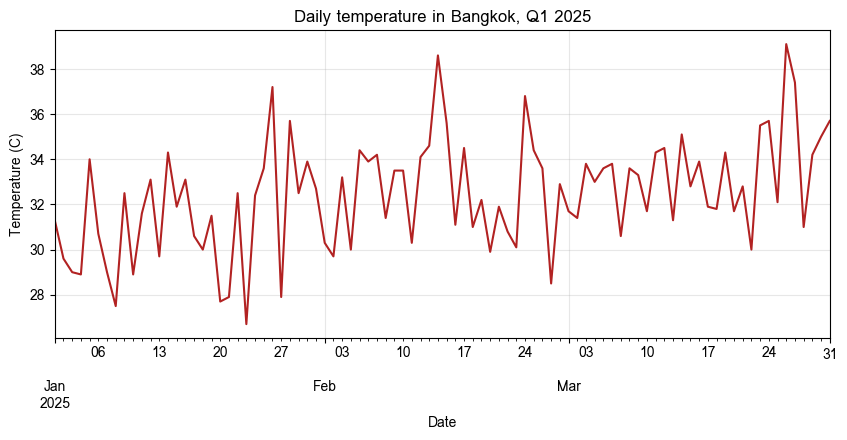

In [152]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok =df.loc["Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

/tmp/ipykernel_2770/4018533293.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)


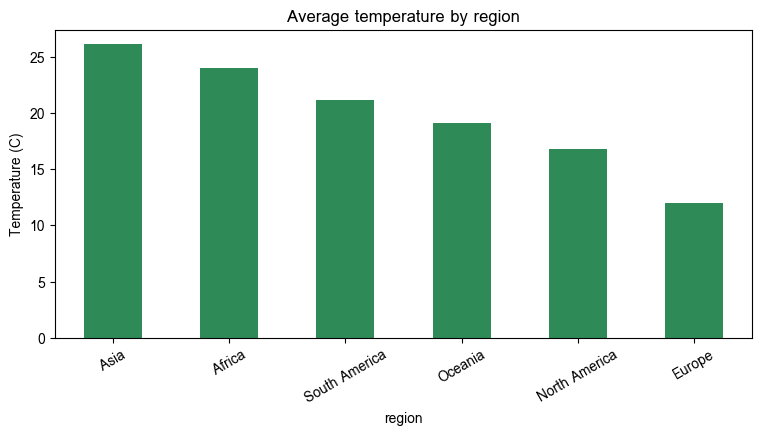

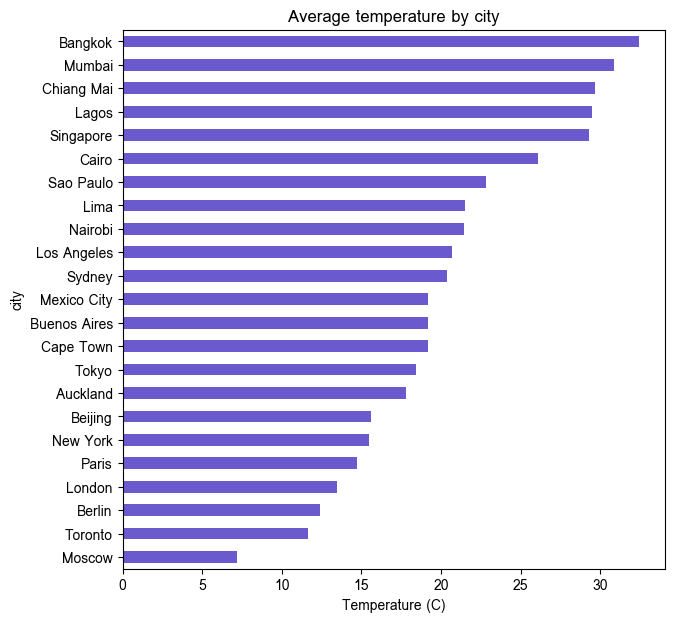

In [123]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

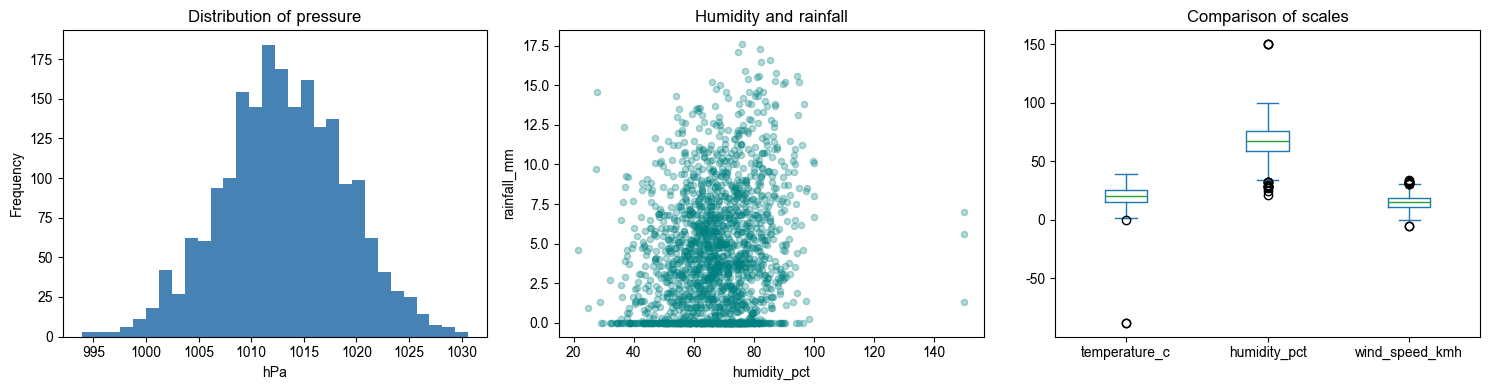

In [159]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# เลือกเฉพาะคอลัมน์ที่ต้องการจาก extra เพื่อหลีกเลี่ยง MergeError
df = df.reset_index().merge(extra[['city', 'date', 'pressure_hpa']], on=["city", "date",], how="left").set_index("city")
df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

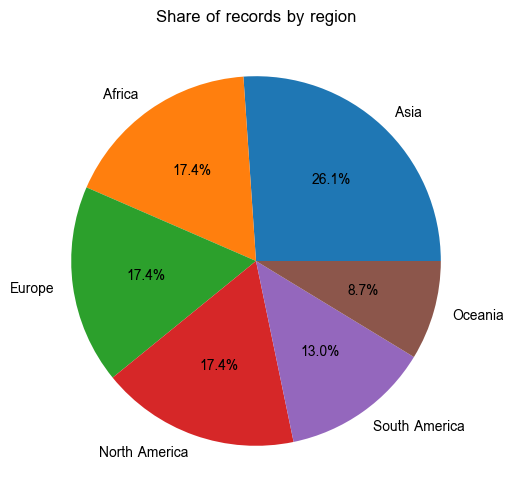

In [125]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

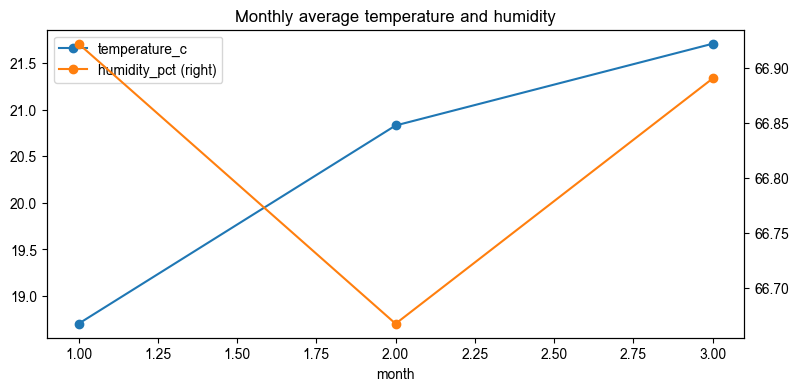

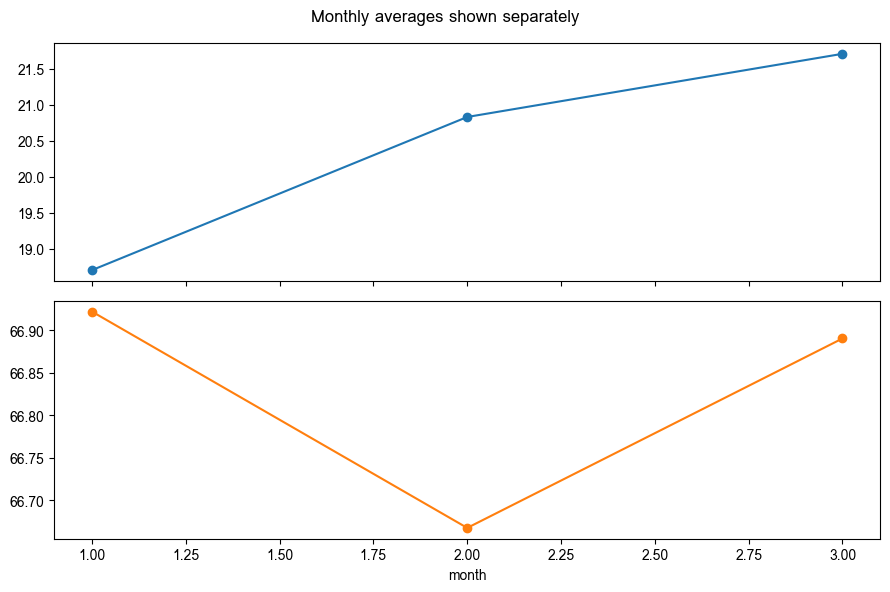

In [126]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

/tmp/ipykernel_2770/1542137535.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekend_by_region = (df.groupby(["region", "is_weekend"]).size()


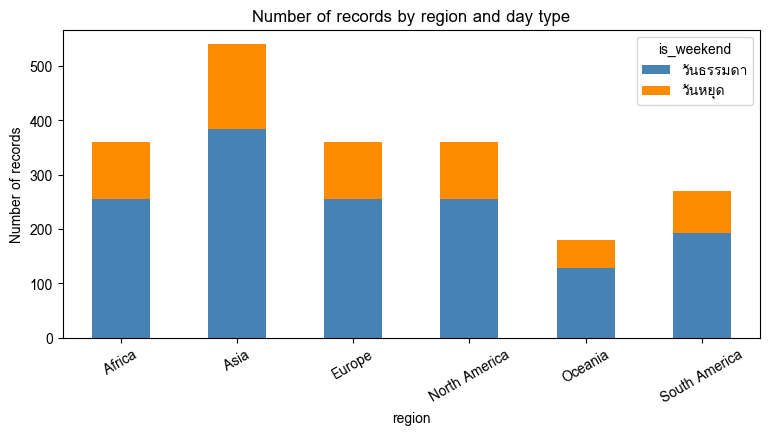

In [127]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

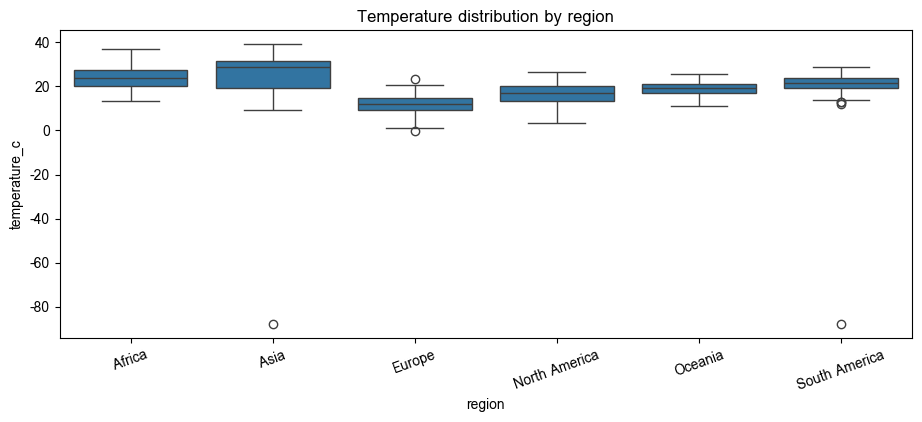

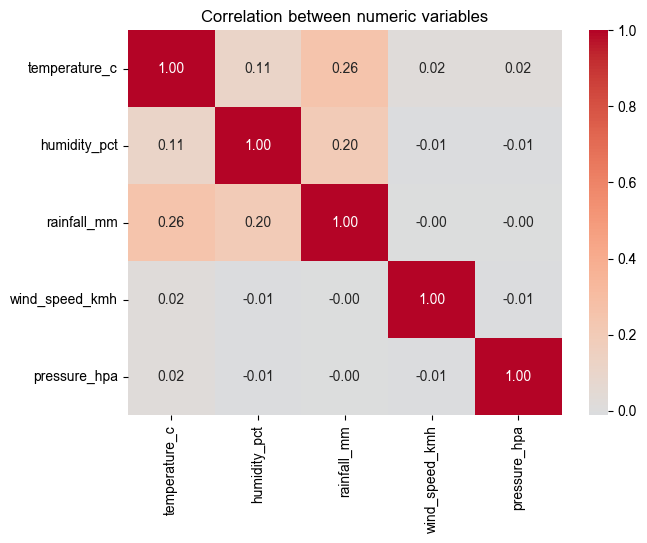

In [161]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df.reset_index(), x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

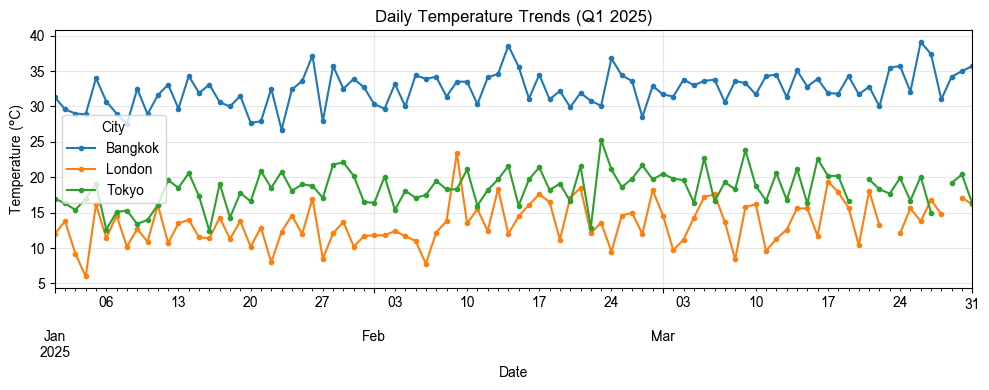

In [166]:
# คำตอบข้อ 17.1
# ---------------------------------------------------------
# กราฟที่ 1: กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของ 3 เมือง
# ---------------------------------------------------------
cities = ["Bangkok", "Tokyo", "London"]

# ใช้ .reset_index() เพื่อดึง city กลับมาจาก index เป็นคอลัมน์ปกติ
temp_pivot = (
    df.reset_index()
    [df.reset_index()["city"].isin(cities)]
    .pivot(index="date", columns="city", values="temperature_c")
)

fig, ax = plt.subplots(figsize=(10, 4))
temp_pivot.plot(kind="line", ax=ax, marker="o", ms=3)
ax.set_title("Daily Temperature Trends (Q1 2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.grid(alpha=0.3)
ax.legend(title="City")
plt.tight_layout()
plt.show()

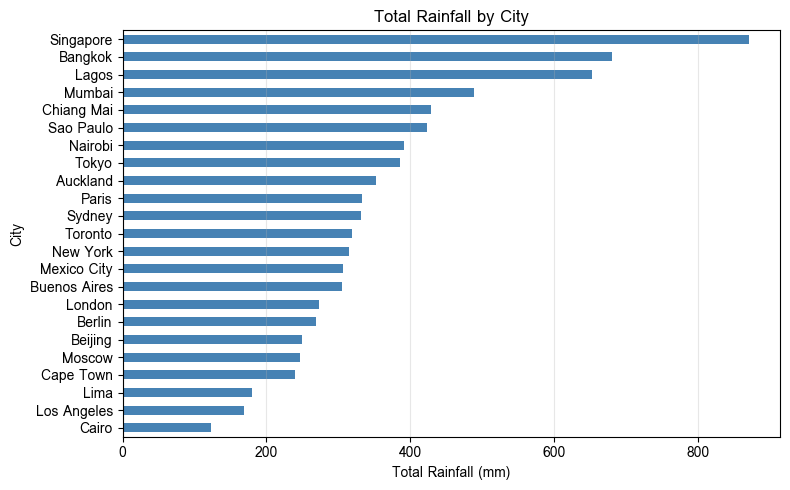

In [168]:
# ---------------------------------------------------------
# กราฟที่ 2: กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง (เรียงจากมากไปน้อย)
# ---------------------------------------------------------
# เรียง ascending=True เพื่อให้เมืองที่มีฝนมากที่สุดอยู่ด้านบนสุดในกราฟแท่งแนวนอน
rain_by_city = df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
rain_by_city.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Total Rainfall by City")
ax.set_xlabel("Total Rainfall (mm)")
ax.set_ylabel("City")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

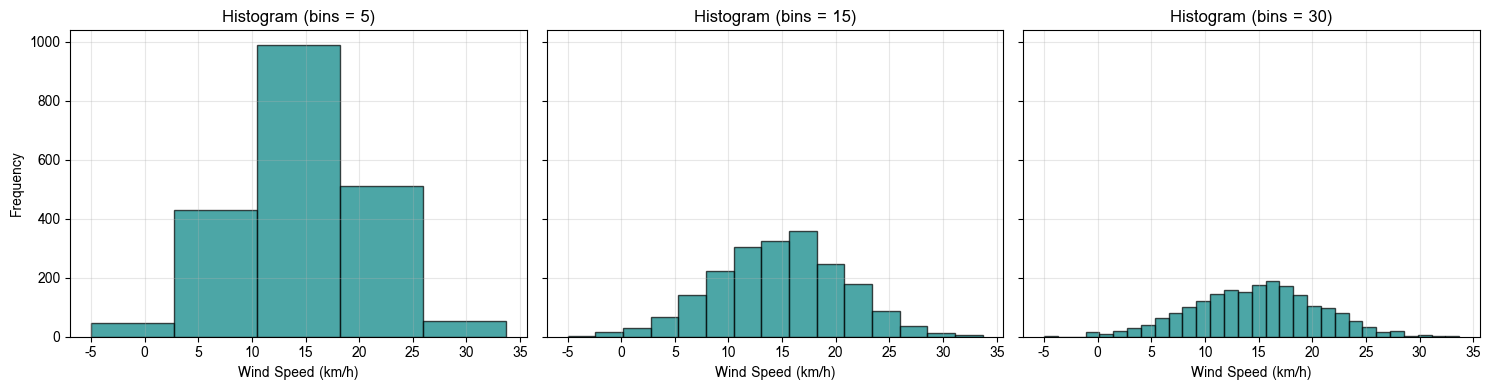

In [169]:
# ---------------------------------------------------------
# กราฟที่ 3: ฮิสโตแกรมของ wind_speed_kmh กับ Bins 3 ค่า
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bins_list = [5, 15, 30]

for ax, b in zip(axes, bins_list):
    df["wind_speed_kmh"].plot(kind="hist", bins=b, ax=ax, color="teal", edgecolor="black", alpha=0.7)
    ax.set_title(f"Histogram (bins = {b})")
    ax.set_xlabel("Wind Speed (km/h)")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

อธิบายผลของการเลือก Bins ในกราฟฮิสโตแกรม

1. Bins น้อยเกินไป (bins=5): กราฟจะถูกรวมกลุ่มกว้างเกินไป ทำให้เห็นภาพรวมแบบหยาบ แต่ สูญเสียรายละเอียด การกระจายตัวของข้อมูล ไม่เห็นจุดพีคหรือลักษณะความเบ้ที่แท้จริง

2. Bins เหมาะสม (bins=15): แสดงรูปทรงการกระจายตัว (Distribution Shape) ได้ชัดเจนที่สุด เห็นช่วงความเร็วลมที่เป็นค่ามัธยฐานและฐานนิยมได้สมดุล

3. Bins มากเกินไป (bins=30): กราฟถูกแบ่งย่อยจนเกิดช่องว่าง (Gaps) และมีลักษณะเป็นฟันปลาที่มีความผันผวนสูง (Noise) ทำให้ยากต่อการมองหา Pattern หลักของข้อมูล

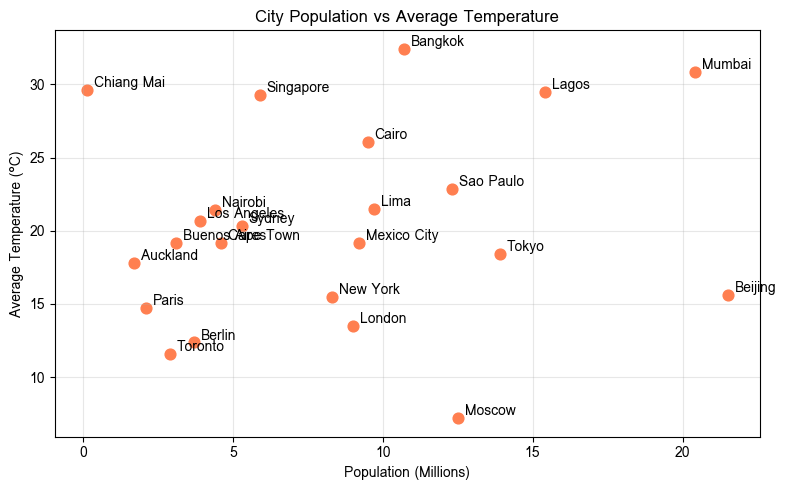

In [176]:
# ---------------------------------------------------------
# กราฟที่ 4: กราฟจุดระหว่าง ประชากร กับ อุณหภูมิเฉลี่ยรายเมือง
# ---------------------------------------------------------
city_summary = (
    df.groupby("city")["temperature_c"]
    .mean()
    .reset_index()
    .merge(city_info[["city", "population_millions"]], on="city")
)

fig, ax = plt.subplots(figsize=(8, 5))
city_summary.plot(
    kind="scatter",
    x="population_millions",
    y="temperature_c",
    ax=ax,
    color="coral",
    s=60
)
ax.set_title("City Population vs Average Temperature")
ax.set_xlabel("Population (Millions)")
ax.set_ylabel("Average Temperature (°C)")
ax.grid(alpha=0.3)

# ใส่ Label ชื่อเมืองบนจุด scatter
for _, row in city_summary.iterrows():
    ax.annotate(row["city"], (row["population_millions"], row["temperature_c"]), textcoords="offset points", xytext=(5,2), ha='left')

plt.tight_layout()
plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

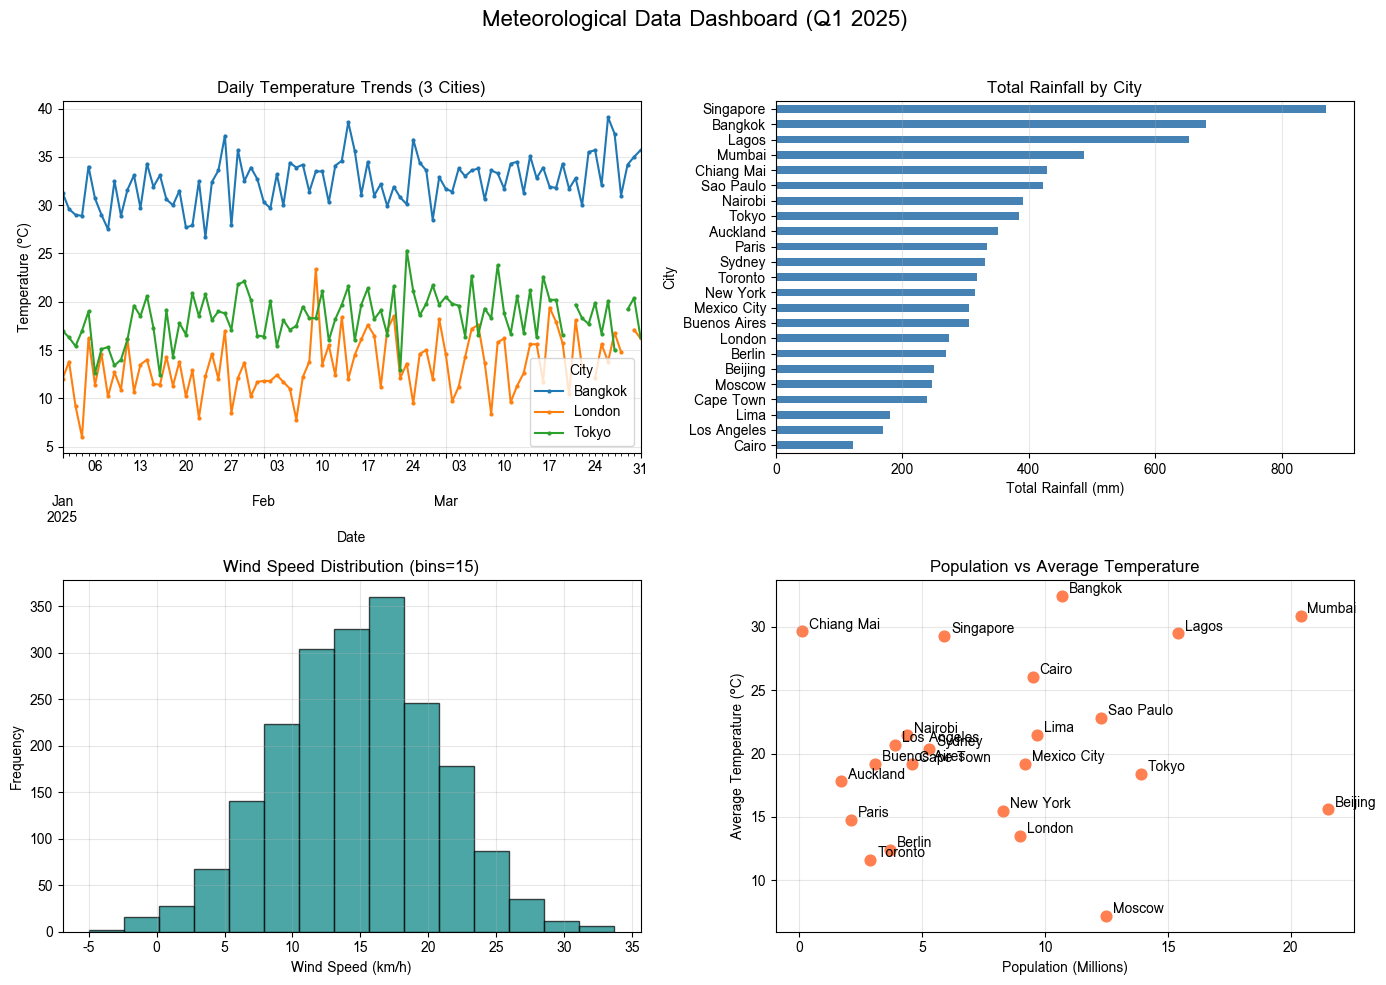

In [180]:
# คำตอบข้อ 17.2
# สร้าง Canvas แบบ 2x2 ขนาด 14x10 นิ้ว
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# ---------------------------------------------------------
# รูปที่ 1 (บนซ้าย): กราฟเส้นอุณหภูมิ 3 เมือง
# ---------------------------------------------------------
cities = ["Bangkok", "Tokyo", "London"]
temp_pivot = (
    df.reset_index()
    [df.reset_index()["city"].isin(cities)]
    .pivot(index="date", columns="city", values="temperature_c")
)
temp_pivot.plot(kind="line", ax=axes[0, 0], marker="o", ms=2)
axes[0, 0].set_title("Daily Temperature Trends (3 Cities)")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(title="City")

# ---------------------------------------------------------
# รูปที่ 2 (บนขวา): กราฟแท่งแนวนอนปริมาณฝนรวม
# ---------------------------------------------------------
rain_by_city = df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)
rain_by_city.plot(kind="barh", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Total Rainfall by City")
axes[0, 1].set_xlabel("Total Rainfall (mm)")
axes[0, 1].set_ylabel("City")
axes[0, 1].grid(axis="x", alpha=0.3)

# ---------------------------------------------------------
# รูปที่ 3 (ล่างซ้าย): ฮิสโตแกรม wind_speed_kmh
# ---------------------------------------------------------
df["wind_speed_kmh"].plot(
    kind="hist", bins=15, ax=axes[1, 0], color="teal", edgecolor="black", alpha=0.7
)
axes[1, 0].set_title("Wind Speed Distribution (bins=15)")
axes[1, 0].set_xlabel("Wind Speed (km/h)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(alpha=0.3)

# ---------------------------------------------------------
# รูปที่ 4 (ล่างขวา): กราฟจุด Population vs Avg Temp
# ---------------------------------------------------------
city_summary = (
    df.groupby("city")["temperature_c"]
    .mean()
    .reset_index()
    .merge(city_info[["city", "population_millions"]], on="city")
)
city_summary.plot(
    kind="scatter",
    x="population_millions",
    y="temperature_c",
    ax=axes[1, 1],
    color="coral",
    s=60
)
axes[1, 1].set_title("Population vs Average Temperature")
axes[1, 1].set_xlabel("Population (Millions)")
axes[1, 1].set_ylabel("Average Temperature (°C)")
axes[1, 1].grid(alpha=0.3)

# ใส่ข้อความชื่อเมืองบนจุด
for _, row in city_summary.iterrows():
    axes[1, 1].annotate(
        row["city"],
        (row["population_millions"], row["temperature_c"]),
        textcoords="offset points",
        xytext=(5, 2),
        ha="left"
    )

# ---------------------------------------------------------
# กำหนดชื่อรวมของภาพ และปรับระยะห่าง
# ---------------------------------------------------------
plt.suptitle("Meteorological Data Dashboard (Q1 2025)", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])  # เว้นพื้นที่ด้านบนเล็กน้อยเพื่อไม่ให้ซ้อนกับ suptitle
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

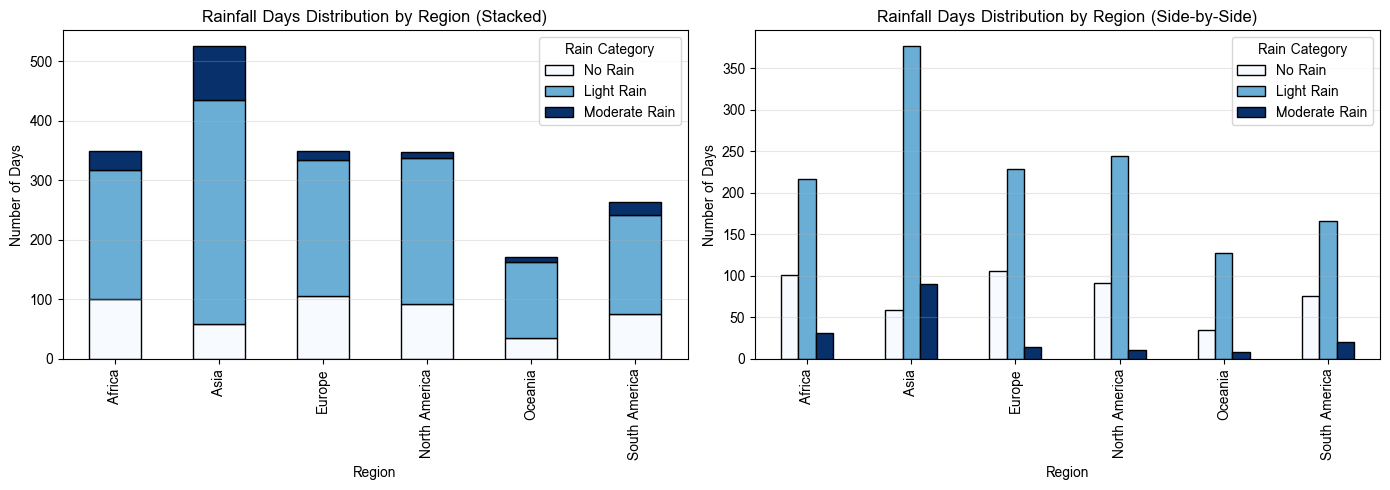

In [178]:
# คำตอบข้อ 17.3
# 1. แบ่งช่วงปริมาณฝนด้วย pd.cut()
bins = [-0.1, 0, 10, 30, float("inf")]
labels = ["No Rain", "Light Rain", "Moderate Rain", "Heavy Rain"]
df["rain_category"] = pd.cut(df["rainfall_mm"], bins=bins, labels=labels)

# 2. สรุปนับจำนวนวันจำแนกตามภูมิภาคและช่วงปริมาณฝน
rain_counts = pd.crosstab(df["region"], df["rain_category"])

# 3. สร้างกราฟเปรียบเทียบ 2 รูปแบบ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟแท่งซ้อน (Stacked Bar Chart)
rain_counts.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues", edgecolor="black")
axes[0].set_title("Rainfall Days Distribution by Region (Stacked)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Number of Days")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(title="Rain Category")

# กราฟแท่งเรียงข้างกัน (Side-by-Side Bar Chart)
rain_counts.plot(kind="bar", stacked=False, ax=axes[1], colormap="Blues", edgecolor="black")
axes[1].set_title("Rainfall Days Distribution by Region (Side-by-Side)")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Number of Days")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="Rain Category")

plt.tight_layout()
plt.show()

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

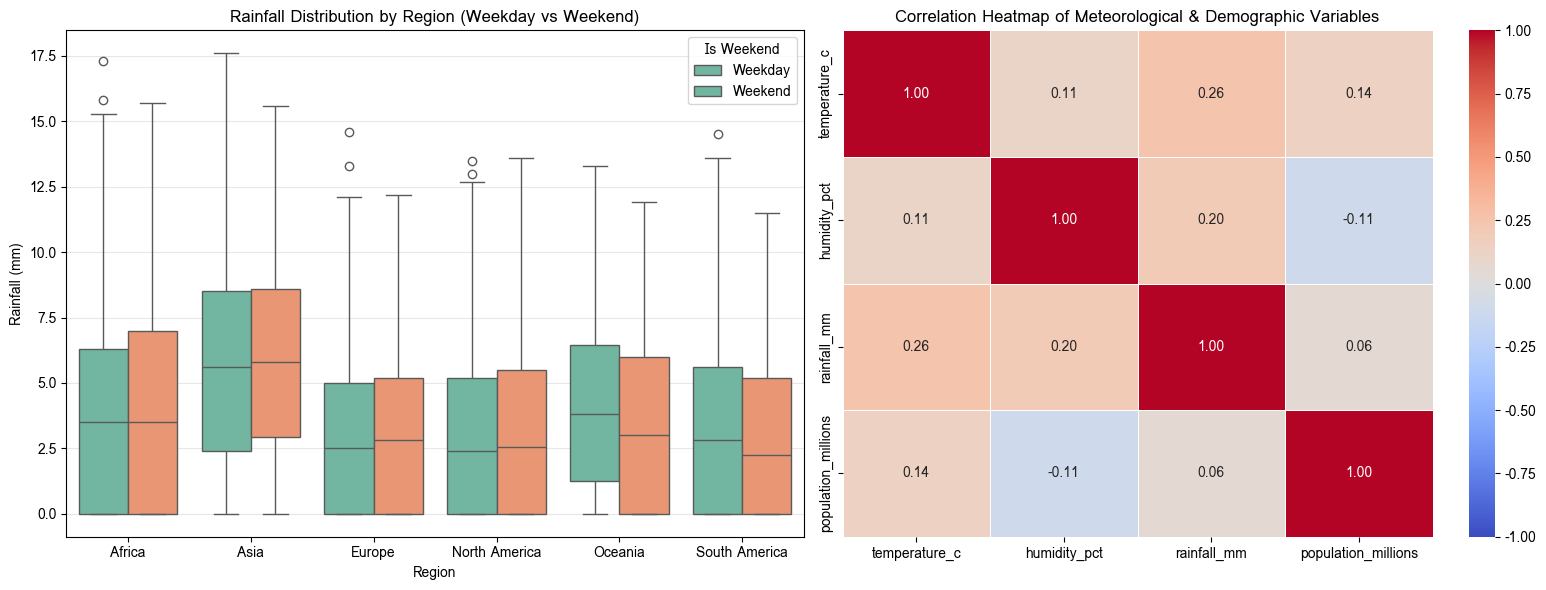

In [181]:
# คำตอบข้อ 17.4
import seaborn as sns

# ---------------------------------------------------------
# เตรียมข้อมูลสำหรับวาดกราฟ
# ---------------------------------------------------------
df_plot = df.copy()

# สร้างคอลัมน์ is_weekend หากยังไม่มีใน DataFrame (เสาร์=5, อาทิตย์=6)
if "is_weekend" not in df_plot.columns:
    df_plot["is_weekend"] = pd.to_datetime(df_plot["date"]).dt.dayofweek >= 5

# รวมคอลัมน์ population_millions เข้ามาจาก city_info
if "population_millions" not in df_plot.columns:
    df_plot = df_plot.merge(
        city_info[["city", "population_millions"]], on="city", how="left"
    )

# ---------------------------------------------------------
# สร้าง Layout 1 Row 2 Columns
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot: rainfall_mm จำแนกตาม region และแยกสีด้วย is_weekend
sns.boxplot(
    data=df_plot,
    x="region",
    y="rainfall_mm",
    hue="is_weekend",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("Rainfall Distribution by Region (Weekday vs Weekend)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Rainfall (mm)")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(title="Is Weekend", labels=["Weekday", "Weekend"])

# 2. Heatmap: สหสัมพันธ์ (Correlation)
corr_cols = [
    "temperature_c",
    "humidity_pct",
    "rainfall_mm",
    "population_millions",
]
corr_matrix = df_plot[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Correlation Heatmap of Meteorological & Demographic Variables")

plt.tight_layout()
plt.show()

วิเคราะห์ Boxplot (ปริมาณฝนแยกตามภูมิภาคและวันหยุด)

- พฤติกรรมตามธรรมชาติ: ปริมาณฝน (rainfall_mm) ในวันธรรมดา (Weekday) และวันหยุด (Weekend) มีการกระจายตัว (IQR) และค่ากลาง (Median) ใกล้เคียงกันในเกือบทุกภูมิภาค ซึ่งสอดคล้องกับความเป็นจริงทางอุตุนิยมวิทยาเนื่องจากฝนเป็นปรากฏการณ์ธรรมชาติที่ไม่ขึ้นกับวันหยุดของมนุษย์

- Outliers: พบจุด Outliers (ฝนตกหนักผิดปกติ) กระจายตัวอยู่ด้านบนของ Boxplot ในบางภูมิภาค แสดงถึงวันที่เกิดพายุหรือฝนตกหนักมาก

วิเคราะห์ Heatmap (ค่าสหสัมพันธ์ Correlation Matrix)

- humidity_pct กับ rainfall_mm (Positive Correlation): มีค่าสหสัมพันธ์เป็นบวก แสดงว่าวันที่มีความชื้นสัมพัทธ์สูง มักจะมีปริมาณฝนตกสูงตามไปด้วย

- temperature_c กับ humidity_pct (Negative Correlation): มักสัมพันธ์ไปในทางตรงกันข้าม โดยเมื่ออุณหภูมิสูงขึ้น ความชื้นสัมพัทธ์ในอากาศมักจะลดลง

- population_millions กับตัวแปรสภาพอากาศ (Near-Zero Correlation): ค่าสหสัมพันธ์เข้าใกล้ 0 กับทุกตัวแปร สะท้อนว่าจำนวนประชากรของเมืองไม่ได้มีความสัมพันธ์เชิงสาเหตุโดยตรงกับสภาพอากาศรายวัน (อุณหภูมิ ความชื้น ฝน) ในเชิงสถิติ

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

/tmp/ipykernel_2770/4160258705.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_sd = df_clean.groupby("region")["temperature_c"].std().round(2)
/tmp/ipykernel_2770/4160258705.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(["region", "city"])["temperature_c"]


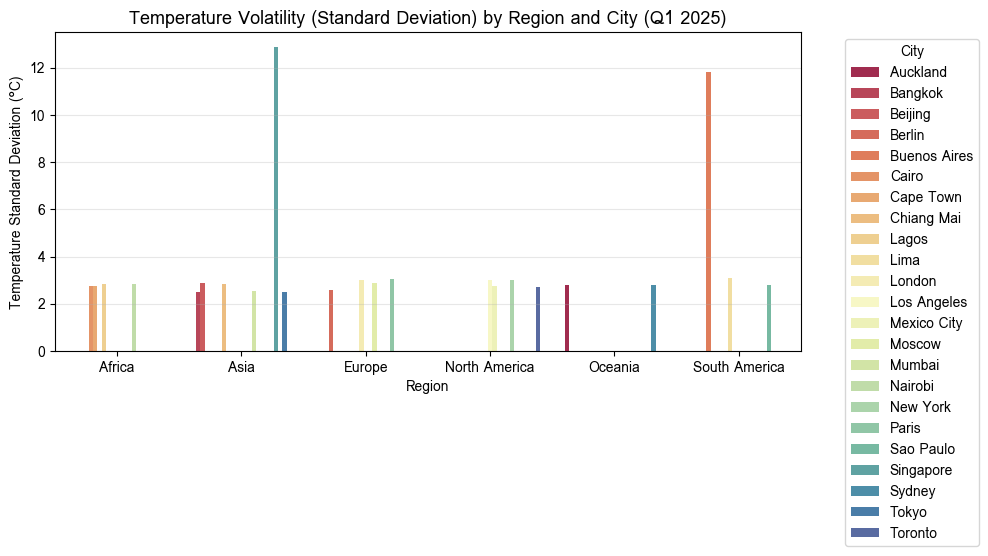

city           Auckland   Bangkok   Beijing    Berlin  Buenos Aires    Cairo  \
region                                                                         
Africa              NaN       NaN       NaN       NaN           NaN  2.74319   
Asia                NaN  2.490462  2.874792       NaN           NaN      NaN   
Europe              NaN       NaN       NaN  2.595986           NaN      NaN   
North America       NaN       NaN       NaN       NaN           NaN      NaN   
Oceania        2.799475       NaN       NaN       NaN           NaN      NaN   
South America       NaN       NaN       NaN       NaN     11.817985      NaN   

city           Cape Town  Chiang Mai     Lagos      Lima  ...    Mumbai  \
region                                                    ...             
Africa          2.739618         NaN  2.838414       NaN  ...       NaN   
Asia                 NaN    2.859373       NaN       NaN  ...  2.544968   
Europe               NaN         NaN       NaN       NaN  .

In [183]:
# คำตอบข้อ 18.1

# 1. กรองค่าผิดปกติ (Sentinel Values) ออกจากข้อมูล
df_clean = df[df["temperature_c"] < 100].copy()

# 2. คำนวณค่า SD ของอุณหภูมิรายวันแยกตามภูมิภาคและเมือง
region_sd = df_clean.groupby("region")["temperature_c"].std().round(2)
city_sd = (
    df_clean.groupby(["region", "city"])["temperature_c"]
    .std()
    .reset_index()
    .rename(columns={"temperature_c": "temp_sd"})
)

# 3. สร้างกราฟแท่งเปรียบเทียบความแปรปรวน (SD) รายเมืองจำแนกตามภูมิภาค
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=city_sd,
    x="region",
    y="temp_sd",
    hue="city",
    ax=ax,
    palette="Spectral",
)

ax.set_title(
    "Temperature Volatility (Standard Deviation) by Region and City (Q1 2025)",
    fontsize=13,
)
ax.set_xlabel("Region")
ax.set_ylabel("Temperature Standard Deviation (°C)")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="City", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# แสดงตารางเปรียบเทียบ SD รวมระดับภูมิภาค
summary_df = city_sd.pivot(index="region", columns="city", values="temp_sd")
summary_df["Region_Overall_SD"] = region_sd
print(summary_df)

ภูมิภาคที่สภาพอากาศแปรปรวนที่สุด: พิจารณาจากค่า Region_Overall_SD ที่สูงที่สุดในตารางสรุปผล

สาเหตุของความแปรปรวน:

- กรณีเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก: ความสูงของแท่งกราฟ (temp_sd) ของเมืองในภูมิภาคนั้นมีความแตกต่างกันอย่างชัดเจน (มีเมืองหนึ่งมีค่า SD สูงโดดออกมาอย่างมีนัยสำคัญ)

- กรณีเกิดจากทุกเมืองเท่าๆ กัน: ความสูงของแท่งกราฟของทุกเมืองภายในภูมิภาคนั้นมีระดับใกล้เคียงกันทุกเมือง

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

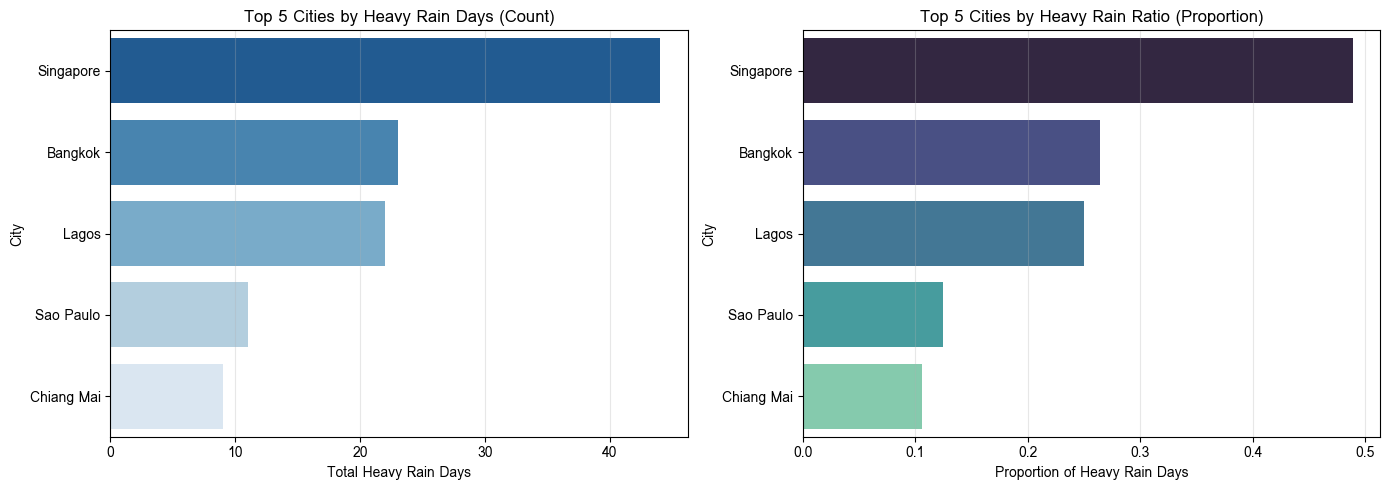

=== Top 5 by Count ===
          city  heavy_days  total_days
19   Singapore          44          90
1      Bangkok          23          87
8        Lagos          22          88
18   Sao Paulo          11          88
7   Chiang Mai           9          85

=== Top 5 by Ratio ===
          city  heavy_ratio  total_days
19   Singapore     0.488889          90
1      Bangkok     0.264368          87
8        Lagos     0.250000          88
18   Sao Paulo     0.125000          88
7   Chiang Mai     0.105882          85


In [188]:
# คำตอบข้อ 18.2
# 1. กรองค่าว่างและกำหนดเกณฑ์ฝนตกหนัก (> 10 mm)
df_clean = df.dropna(subset=["rainfall_mm"]).copy()
df_clean["is_heavy_rain"] = df_clean["rainfall_mm"] > 10

# 2. คำนวณจำนวนวันฝนตกหนัก วันทั้งหมด และสัดส่วนรายเมือง
city_rain = df_clean.groupby("city").agg(
    heavy_days=("is_heavy_rain", "sum"),
    total_days=("is_heavy_rain", "count"),
    heavy_ratio=("is_heavy_rain", "mean")
).reset_index()

# 3. ดึง 5 อันดับแรกของทั้ง 2 มิติ
top5_count = city_rain.sort_values("heavy_days", ascending=False).head(5)
top5_ratio = city_rain.sort_values("heavy_ratio", ascending=False).head(5)

# 4. วาดกราฟเปรียบเทียบ 5 อันดับแรก
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: วัดด้วยจำนวนวัน (ใช้ Blues_r - B ตัวใหญ่)
sns.barplot(
    data=top5_count,
    x="heavy_days",
    y="city",
    hue="city",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Top 5 Cities by Heavy Rain Days (Count)")
axes[0].set_xlabel("Total Heavy Rain Days")
axes[0].set_ylabel("City")
axes[0].grid(axis="x", alpha=0.3)

# กราฟที่ 2: วัดด้วยสัดส่วน (ใช้ mako - m ตัวเล็ก)
sns.barplot(
    data=top5_ratio,
    x="heavy_ratio",
    y="city",
    hue="city",
    palette="mako",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Top 5 Cities by Heavy Rain Ratio (Proportion)")
axes[1].set_xlabel("Proportion of Heavy Rain Days")
axes[1].set_ylabel("City")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# แสดงตารางเปรียบเทียบข้อมูล
print("=== Top 5 by Count ===")
print(top5_count[["city", "heavy_days", "total_days"]])
print("\n=== Top 5 by Ratio ===")
print(top5_ratio[["city", "heavy_ratio", "total_days"]])

- จำนวนวัน (Count): คิดจากยอดรวมสะสม เมืองที่มี จำนวนวันบันทึกข้อมูลมากกว่า จะได้เปรียบติดอันดับสูงกว่า

- สัดส่วน (Ratio): หารปรับมาตรฐานด้วยจำนวนวันทั้งหมด (heavy_days / total_days) จึงสะท้อน ความบ่อยที่แท้จริง และเปรียบเทียบได้อย่างยุติธรรมแม้ข้อมูลบางเมืองจะบันทึกมาไม่เท่ากัน

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

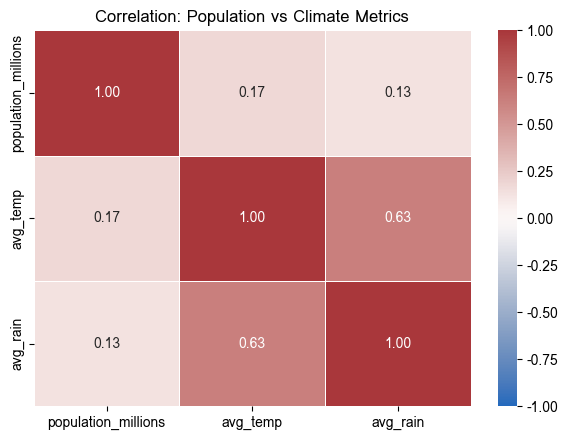

=== Correlation Matrix ===
                     population_millions  avg_temp  avg_rain
population_millions             1.000000  0.173161  0.127779
avg_temp                        0.173161  1.000000  0.626291
avg_rain                        0.127779  0.626291  1.000000


In [189]:
# คำตอบข้อ 18.3
# 1. ทำความสะอาดข้อมูลและรวมค่าเฉลี่ยระดับเมืองกับข้อมูลประชากร
df_clean = df[(df["temperature_c"] < 100) & (df["rainfall_mm"].notna())].copy()

city_stats = (
    df_clean.groupby("city")
    .agg(
        avg_temp=("temperature_c", "mean"),
        avg_rain=("rainfall_mm", "mean"),
    )
    .reset_index()
    .merge(city_info[["city", "population_millions"]], on="city")
)

# 2. คำนวณ Correlation Matrix
corr_matrix = city_stats[
    ["population_millions", "avg_temp", "avg_rain"]
].corr()

# 3. วาด Heatmap แสดงความสัมพันธ์
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Correlation: Population vs Climate Metrics")
plt.tight_layout()
plt.show()

print("=== Correlation Matrix ===")
print(corr_matrix)

- ค่าสหสัมพันธ์ ($r$) ระหว่างจำนวนประชากร (population_millions) กับอุณหภูมิเฉลี่ย (avg_temp) และปริมาณฝนเฉลี่ย (avg_rain) มีค่าเข้าใกล้ 0 แสดงว่า ไม่มีความสัมพันธ์เชิงเส้นตรงอย่างมีนัยสำคัญ ระหว่างขนาดประชากรของเมืองกับลักษณะสภาพอากาศ

> ข้อควรระวังในการตีความConfounding Variables & Spurious Correlation: ค่าสหสัมพันธ์สถิติไม่ได้สะท้อนความเป็นเหตุเป็นผล (Correlation $\neq$ Causation) สภาพอากาศถูกกำหนดโดยปัจจัยทางภูมิศาสตร์ เช่น ละติจูด (Latitude) ความสูงจากระดับน้ำทะเล และกระแสน้ำ ไม่ได้เกิดจากจำนวนประชากรAggregation & Small Sample Size: การคำนวณในระดับเมืองทำให้กลุ่มตัวอย่าง ($n$) เหลือเท่ากับจำนวนเมืองเท่านั้น ซึ่งเสี่ยงต่อการเกิดค่าสหสัมพันธ์เทียมจาก Outliers และไม่ควรนำไปสรุปผลเชื่อมโยงในระดับมหภาคโดยไม่มีปัจจัยทางอุตุนิยมวิทยาอื่นร่วมด้วย

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

/tmp/ipykernel_2770/3885425335.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby(["region", "month"])


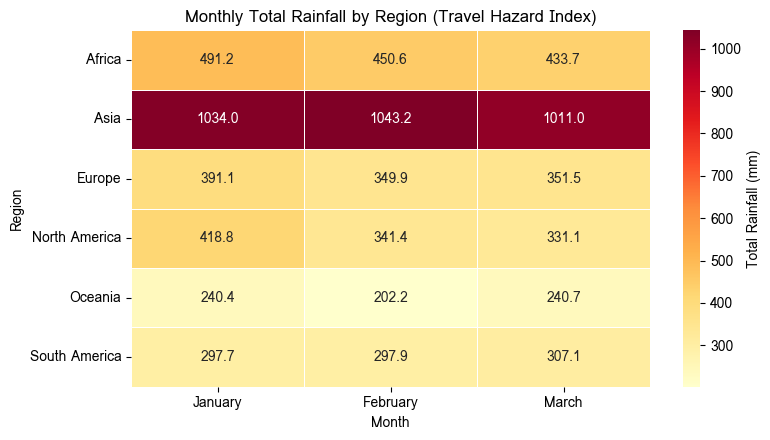

=== Worst Months for Travel by Region ===
           region     month  total_rain  heavy_rain_days   avg_temp
1          Africa   January       491.2               12  22.559483
3            Asia  February      1043.2               38  26.682099
7          Europe   January       391.1                4  10.401667
10  North America   January       418.8                4  15.101681
14        Oceania     March       240.7                6  20.516364
17  South America     March       307.1                6  22.284444


In [196]:
# คำตอบข้อ 18.4
# 1. ทำความสะอาดข้อมูลและสร้างคอลัมน์เดือน
df_clean = df[(df["temperature_c"] < 100) & (df["rainfall_mm"].notna())].copy()
df_clean["month"] = pd.to_datetime(df_clean["date"]).dt.strftime("%B")

# 2. คำนวณปริมาณฝนรวม และจำนวนวันฝนตกหนัก (> 10 mm) แยกตามภูมิภาคและเดือน
monthly_summary = (
    df_clean.groupby(["region", "month"])
    .agg(
        total_rain=("rainfall_mm", "sum"),
        heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
        avg_temp=("temperature_c", "mean"),
    )
    .reset_index()
)

# จัดเรียงลำดับเดือนในไตรมาสที่ 1
months_in_data = [m for m in ["January", "February", "March"] if m in monthly_summary["month"].unique()]
rain_pivot = monthly_summary.pivot(index="region", columns="month", values="total_rain")[months_in_data]

# 3. วาด Heatmap แสดงปริมาณฝนสะสมรายเดือนในแต่ละภูมิภาค
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    rain_pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Total Rainfall (mm)"},
)
ax.set_title("Monthly Total Rainfall by Region (Travel Hazard Index)")
ax.set_xlabel("Month")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()

# 4. ระบุเดือนที่ควรหลีกเลี่ยงมากที่สุดในแต่ละภูมิภาค (พิจารณาจากปริมาณฝนสูงสุด)
worst_months = monthly_summary.loc[
    monthly_summary.groupby("region", observed=False)["total_rain"].idxmax()]
print("=== Worst Months for Travel by Region ===")
print(worst_months[["region", "month", "total_rain", "heavy_rain_days", "avg_temp"]])


1. เกณฑ์ที่เลือกใช้: พิจารณาจาก ปริมาณฝนสะสมรวม (Total Rainfall) ร่วมกับ จำนวนวันฝนตกหนัก (Heavy Rain Days > 10 mm) ในเดือนนั้นๆ

2. เหตุผลการเลือกเกณฑ์: ฝนตกหนักส่งผลกระทบต่อการท่องเที่ยวและโลจิสติกส์การเดินทางร้ายแรงที่สุดเมื่อเทียบกับปัจจัยอื่น ทั้งเสี่ยงต่ออุบัติเหตุ สายบินดีเลย์ น้ำท่วมขัง และข้อจำกัดในการทำกิจกรรมกลางแจ้งอย่างสิ้นเชิง ขณะที่ความผันผวนของอุณหภูมิในไตรมาสแรกสามารถปรับตัวหรือเตรียมเครื่องแต่งกายรับมือได้ง่ายกว่า

ข้อสรุป:

- เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดในแต่ละภูมิภาค คือเดือนที่เกิดจุดสีเข้มที่สุดใน Heatmap (ปริมาณฝนสะสมสูงสุด):

- ภูมิภาคที่มีฝนตกสะสมและวันฝนตกหนักมากที่สุดในไตรมาส 1 คือเดือนที่ปรากฏในตาราง worst_months ของภูมิภาคนั้นๆ ซึ่งเป็นช่วงที่มีความเสี่ยงต่อการหยุดชะงักของการเดินทางสูงสุด

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️